In [1]:
import re
import sys
from datetime import datetime, date, timedelta

import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
from termcolor import colored
from time import sleep

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

import statsmodels.api as sm
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMRegressor
from sklearn.metrics import make_scorer, mean_squared_error
import numpy as np





#sys.stdout.reconfigure(encoding='utf-8')

teams = ["Diamondbacks", "Braves", "Orioles", "Red Sox", "Cubs", "White Sox",
            "Reds", "Guardians", "Rockies", "Tigers", "Astros", "Royals",
            "Angels", "Dodgers", "Marlins", "Brewers", "Twins", "Mets",
            "Yankees", "Athletics", "Phillies", "Pirates", "Padres", "Giants",
            "Mariners", "Cardinals", "Rays", "Rangers", "Blue Jays", "Nationals"]


### fcns

In [2]:
def check_team_names(team1, team2):
    if team1 == "D-backs" or team1 == "Arizona Diamondbacks":
        team1 = "Diamondbacks"
    elif team1 == "Atlanta Braves":
        team1 = "Braves"
    elif team1 == "Baltimore Orioles":
        team1 = "Orioles"
    elif team1 == "Boston Red Sox":
        team1 = "Red Sox"
    elif team1 == "Chicago Cubs":
        team1 = "Cubs"
    elif team1 == "Chicago White Sox":
        team1 = "White Sox"
    elif team1 == "Cincinnati Reds":
        team1 = "Reds"
    elif team1 == "Cleveland Guardians":
        team1 = "Guardians"
    elif team1 == "Colorado Rockies":
        team1 = "Rockies"
    elif team1 == "Detroit Tigers":
        team1 = "Tigers"
    elif team1 == "Houston Astros":
        team1 = "Astros"
    elif team1 == "Kansas City Royals":
        team1 = "Royals"
    elif team1 == "Los Angeles Angels":
        team1 = "Angels"
    elif team1 == "Los Angeles Dodgers":
        team1 = "Dodgers"
    elif team1 == "Miami Marlins":
        team1 = "Marlins"
    elif team1 == "Milwaukee Brewers":
        team1 = "Brewers"
    elif team1 == "Minnesota Twins":
        team1 = "Twins"
    elif team1 == "New York Mets":
        team1 = "Mets"
    elif team1 == "New York Yankees":
        team1 = "Yankees"
    elif team1 == "Philadelphia Phillies":
        team1 = "Phillies"
    elif team1 == "Pittsburgh Pirates":
        team1 = "Pirates"
    elif team1 == "San Diego Padres":
        team1 = "Padres"
    elif team1 == "San Francisco Giants":
        team1 = "Giants"
    elif team1 == "Seattle Mariners":
        team1 = "Mariners"
    elif team1 == "St. Louis Cardinals":
        team1 = "Cardinals"
    elif team1 == "Tampa Bay Rays":
        team1 = "Rays"
    elif team1 == "Texas Rangers":
        team1 = "Rangers"
    elif team1 == "Toronto Blue Jays":
        team1 = "Blue Jays"
    elif team1 == "Washington Nationals":
        team1 = "Nationals"

    if team2 == "D-backs" or team2 == "Arizona Diamondbacks":
        team2 = "Diamondbacks"
    elif team2 == "Atlanta Braves":
        team2 = "Braves"
    elif team2 == "Baltimore Orioles":
        team2 = "Orioles"
    elif team2 == "Boston Red Sox":
        team2 = "Red Sox"
    elif team2 == "Chicago Cubs":
        team2 = "Cubs"
    elif team2 == "Chicago White Sox":
        team2 = "White Sox"
    elif team2 == "Cincinnati Reds":
        team2 = "Reds"
    elif team2 == "Cleveland Guardians":
        team2 = "Guardians"
    elif team2 == "Colorado Rockies":
        team2 = "Rockies"
    elif team2 == "Detroit Tigers":
        team2 = "Tigers"
    elif team2 == "Houston Astros":
        team2 = "Astros"
    elif team2 == "Kansas City Royals":
        team2 = "Royals"
    elif team2 == "Los Angeles Angels":
        team2 = "Angels"
    elif team2 == "Los Angeles Dodgers":
        team2 = "Dodgers"
    elif team2 == "Miami Marlins":
        team2 = "Marlins"
    elif team2 == "Milwaukee Brewers":
        team2 = "Brewers"
    elif team2 == "Minnesota Twins":
        team2 = "Twins"
    elif team2 == "New York Mets":
        team2 = "Mets"
    elif team2 == "New York Yankees":
        team2 = "Yankees"
    elif team2 == "Philadelphia Phillies":
        team2 = "Phillies"
    elif team2 == "Pittsburgh Pirates":
        team2 = "Pirates"
    elif team2 == "San Diego Padres":
        team2 = "Padres"
    elif team2 == "San Francisco Giants":
        team2 = "Giants"
    elif team2 == "Seattle Mariners":
        team2 = "Mariners"
    elif team2 == "St. Louis Cardinals":
        team2 = "Cardinals"
    elif team2 == "Tampa Bay Rays":
        team2 = "Rays"
    elif team2 == "Texas Rangers":
        team2 = "Rangers"
    elif team2 == "Toronto Blue Jays":
        team2 = "Blue Jays"
    elif team2 == "Washington Nationals":
        team2 = "Nationals"

    return team1, team2

In [31]:
# this function gets all of the pitchers and their stats for todays games
def get_pitchers(teams, date):
    # URL of the StatMuse page for today's games
    formatted = date.strftime("%Y-%m-%d")
    url = f"https://www.mlb.com/probable-pitchers/{formatted}"

    # Send a GET request to the URL
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)",
        "Accept-Language": "en-US,en;q=0.9"
    }

    response = requests.get(url, headers=headers)
    response.raise_for_status()

    # Check if the request was successful
    if response.status_code == 200:
        # print(response.status_code)
        soup = BeautifulSoup(response.content, 'html.parser')

        text_content = soup.get_text()
        cleaned_text = "\n".join(line.lstrip() for line in text_content.splitlines() if line.strip())
        # print(cleaned_text)
        lines = cleaned_text.splitlines()
        # print(lines)
        output = []
        output2 = []
        games = []

        # for teams in game:
        for i in range(len(lines) - 2):  # Stop 2 lines early to avoid index errors
            # print(lines[i])
            # print(lines[i+1])
            lines[i], lines[i+2] = check_team_names(lines[i], lines[i+2])
            relevant_lines = []
            # Check for the pattern
            if lines[i].strip() in teams and lines[i+1].strip() == '@' and lines[i+2].strip() in teams:
                # print(teams)
                team1 =lines[i].strip()
                team2 = lines[i+2].strip()
                games.append([team1, team2])
                if i + 14 < len(lines) and lines[i+4].strip() != "warmup" and lines[i+7].split()[0] != "Makeup":
                    if lines[i+4] == 'PPD':
                        continue

                    if len(lines[i+7]) > 7:
                        if lines[i+4].lower() == 'delayed':
                            relevant_lines = lines[i+5:i+11]
                            entry1 = [team1, lines[i+3], 'A', team2, lines[i+8], lines[i+12], lines[i+13], lines[i+14].split()[1]]
                            entry2 = [team2, lines[i+8], 'H', team1, lines[i+3], lines[i+9], lines[i+10], lines[i+11].split()[1]]
                        elif lines[i+4].lower() == 'delay':
                            print('Delay')
                            relevant_lines = lines[i+5:i+11]
                            entry1 = [team1, lines[i+3], 'A', team2, lines[i+8], lines[i+12], lines[i+13], lines[i+14].split()[1]]
                            entry2 = [team2, lines[i+8], 'H', team1, lines[i+3], lines[i+9], lines[i+10], lines[i+11].split()[1]]
                        elif lines[i+7].split()[0] == 'Follows':
                            print("here45")
                            relevant_lines = lines[i+4:i+10]
                            entry1 = [team1, lines[i+3], 'A', team2, lines[i+8], lines[i+12], lines[i+13], lines[i+14].split()[1]]
                            entry2 = [team2, lines[i+8], 'H', team1, lines[i+3], lines[i+9], lines[i+10], lines[i+11].split()[1]]
                        elif lines[i+7].split()[0] == 'Moved':
                            print("Moved")
                            entry1 = [team1, lines[i+3], 'A', team2, lines[i+8], lines[i+12], lines[i+13], lines[i+14].split()[1]]
                            entry2 = [team2, lines[i+8], 'H', team1, lines[i+3], lines[i+9], lines[i+10], lines[i+11].split()[1]]
                        elif lines[i+7] == 'Lou Gehrig Day':
                            print("Lou")
                            entry1 = [team1, lines[i+3], 'A', team2, lines[i+8], lines[i+12], lines[i+13], lines[i+14].split()[1]]
                            entry2 = [team2, lines[i+8], 'H', team1, lines[i+3], lines[i+9], lines[i+10], lines[i+11].split()[1]]
                        elif lines[i+7] == 'Roberto Clemente Day':
                            print("Rob clemente")
                            entry1 = [team1, lines[i+3], 'A', team2, lines[i+8], lines[i+12], lines[i+13], lines[i+14].split()[1]]
                            entry2 = [team2, lines[i+8], 'H', team1, lines[i+3], lines[i+9], lines[i+10], lines[i+11].split()[1]]
                        elif lines[i+7] == 'Jackie Robinson Day':
                            print("Jackie rob")
                            entry1 = [team1, lines[i+3], 'A', team2, lines[i+8], lines[i+12], lines[i+13], lines[i+14].split()[1]]
                            entry2 = [team2, lines[i+8], 'H', team1, lines[i+3], lines[i+9], lines[i+10], lines[i+11].split()[1]]
                        elif lines[i+7].split()[0:4] == ['MLB', 'Little', 'League', 'Classic']:
                            print("Little League Classic")
                            entry1 = [team1, lines[i+3], 'A', team2, lines[i+8], lines[i+12], lines[i+13], lines[i+14].split()[1]]
                            entry2 = [team2, lines[i+8], 'H', team1, lines[i+3], lines[i+9], lines[i+10], lines[i+11].split()[1]]
                        elif lines[i+7].split()[0:3] == ['MLB', 'Speedway', 'Classic']:
                            print("MLB Speedway Classic")
                            entry1 = [team1, lines[i+3], 'A', team2, lines[i+8], lines[i+12], lines[i+13], lines[i+14].split()[1]]
                            entry2 = [team2, lines[i+8], 'H', team1, lines[i+3], lines[i+9], lines[i+10], lines[i+11].split()[1]]
                        else:
                            print("here105")
                            relevant_lines = lines[i:i+15]
                            print(relevant_lines)
                            if lines[i+4] == 'TBD':
                                # print(lines)
                                entry1 = [team1, lines[i+3], 'A', team2, lines[i+9], lines[i+13], lines[i+14], lines[i+15].split()[1]]
                                entry2 = [team2, lines[i+9], 'H', team1, lines[i+3], lines[i+10], lines[i+11], lines[i+12].split()[1]]
                            elif lines[i+4] == 'SUSP':
                                entry1 = [team1, lines[i+3], 'A', team2, lines[i+8], lines[i+12], lines[i+13], lines[i+14].split()[1]]
                                entry2 = [team2, lines[i+8], 'H', team1, lines[i+3], lines[i+9], lines[i+10], lines[i+11].split()[1]]
                            elif lines[i+7].split()[-1].lower() == 'opener' or lines[i+7].split()[-1].lower() == 'ppd':
                                entry1 = [team1, lines[i+3], 'A', team2, lines[i+8], lines[i+12], lines[i+13], lines[i+14].split()[1]]
                                entry2 = [team2, lines[i+8], 'H', team1, lines[i+3], lines[i+9], lines[i+10], lines[i+11].split()[1]]
                            else:
                                entry1 = [team1, lines[i+3], 'A', team2, lines[i+7], lines[i+11], lines[i+12], lines[i+13].split()[1]]
                                entry2 = [team2, lines[i+7], 'H', team1, lines[i+3], lines[i+8], lines[i+9], lines[i+10].split()[1]]

                        output.append([teams, relevant_lines])
                        
                    else:
                        relevant_lines = lines[i+8:i+14]
                        output.append([teams, relevant_lines])
                        
                        if lines[i+8] == 'TBD':
                            print(lines[i:i+12])
                            entry1 = [team1, lines[i+3], 'A', team2, lines[i+7], lines[i+9], lines[i+10], lines[i+11].split()[1]]
                            entry2 = [team2, lines[i+7], 'H', team1, lines[i+3], lines[i+8], lines[i+9], "Nan"]
                        elif lines[i+11] == 'TBD':
                            print(f"relevant lines: {relevant_lines}")
                            entry1 = [team1, lines[i+3], 'A', team2, lines[i+7], lines[i+11], lines[i+12], "Nan"]
                            entry2 = [team2, lines[i+7], 'H', team1, lines[i+3], lines[i+8], lines[i+9], lines[i+10].split()[1]]
                            print(f"entry1: {entry1}")
                            print(f"entry2: {entry2}")
                        else:
                            # print(f"relevant lines else: {relevant_lines}")
                            entry1 = [team1, lines[i+3], 'A', team2, lines[i+7], lines[i+11], lines[i+12], lines[i+13].split()[1]]
                            entry2 = [team2, lines[i+7], 'H', team1, lines[i+3], lines[i+8], lines[i+9], lines[i+10].split()[1]]
                else:
                    if lines[i+4] == 'PPD':
                        continue
                    if len(lines[i+8]) > 10:
                        entry1 = [team1, lines[i+3], 'A', team2, lines[i+9], lines[i+13], lines[i+14], lines[i+15].split()[1]]
                        entry2 = [team2, lines[i+9], 'H', team1, lines[i+3], lines[i+10], lines[i+11], lines[i+12].split()[1]]
                    else:
                        entry1 = [team1, lines[i+3], 'A', team2, lines[i+8], lines[i+12], lines[i+13], lines[i+14].split()[1]]
                        entry2 = [team2, lines[i+8], 'H', team1, lines[i+3], lines[i+9], lines[i+10], lines[i+11].split()[1]]

                # print(entry1)
                output2.append(entry1)
                output2.append(entry2)

        return output2, games

    else:
        print(date)
        print("probable pitchers")
        print(f"Failed to retrieve MLB webpage. Status code: {response.status_code}")



In [4]:
def get_eras(opposing_pitchers, date):
    updated_pitchers = []
    invalid_opps = []
    for p in opposing_pitchers:
        # year_str = date.strftime('%Y')
        try:
            print(f"not going back for {p[5]}, converting: {p[-1]}")
            float(p[-1])
            updated_pitchers.append(p)
        except:
            year_str = str(date.year - 1)

            url = f"https://www.statmuse.com/mlb/ask/{p[5]}-era-{year_str}-season"

            response = requests.get(url)

            # Check if the request was successful
            if response.status_code == 200:
                # print(response.status_code)
                soup = BeautifulSoup(response.content, 'html.parser')

                text_content = soup.get_text()
                lines = text_content.splitlines()
                relevant_line = lines[1]
                start_index = relevant_line.find('an ERA of')
                if start_index != -1:
                    end_index = start_index + len('an ERA of') + 10
                    era = relevant_line[start_index:end_index].split()[3]
                else:
                    print(f"error on {p[5]}")
                    print(relevant_line)
                    # if p[5] == 'Luis Garcia':
                    #     print("here")
                    #     era = 3.35
                    # else:
                    new_start_index = relevant_line.find(p[5], relevant_line.find(p[5]) + len(p[5]))
                    era = relevant_line[new_start_index:].split()[2 * len(p[5].split())]

                new_p = p.copy()
                # new_p.append(era)
                new_p[-1] = era
                updated_pitchers.append(new_p)
            else:
                print(f"cant find {p[5]}'s era page")
                invalid_opps.append(p[0])
                new_p = p.copy()
                # new_p.append(4)
                new_p[-1] = 4
                updated_pitchers.append(new_p)

    return updated_pitchers, invalid_opps



In [5]:
import json
def fetch_mlbodds_for_date(date):
    # 1) Get the scoreboard to discover each game’s IDs and team names
    formatted = date.strftime("%Y%m%d")

    sb_url = "https://site.api.espn.com/apis/site/v2/sports/baseball/mlb/scoreboard"
    sb = requests.get(sb_url, params={"dates": formatted}).json()

    out = []
    for event in sb.get("events", []):
        comp  = event["competitions"][0]
        
        teams = {t["homeAway"]: t["team"]["name"] for t in comp["competitors"]}
        # 2) Pull the core-API odds for that specific game
        odds_url = (
            "https://sports.core.api.espn.com/v2/"
            "sports/baseball/leagues/mlb/"
            f"events/{event['id']}/competitions/{comp['id']}/odds"
        )
        r = requests.get(odds_url)
        r.raise_for_status()
        j = r.json()
        # print(json.dumps(j, indent=2))  # inspect for a 'links' or 'markets' -> 'spreads' ref

        items = j.get("items", [])
        if not items:
            continue

        # 3) Take the first provider’s away/home money-line
        p         = items[0]
        away_ml   = p["awayTeamOdds"]["moneyLine"]
        home_ml   = p["homeTeamOdds"]["moneyLine"]
        away_ml_str  = f"{away_ml:+d}"   # e.g. "-160" or "+105"
        home_ml_str  = f"{home_ml:+d}"   # e.g. "+135" or "-120"

        # Spread line and odds
        try:
            away_spread      = p["awayTeamOdds"]["current"]["pointSpread"]["american"]
        except:
            away_spread      = None
        try:
            away_spread_odds = p["awayTeamOdds"]["current"]["spread"]["american"]
        except:
            away_spread_odds = None
        try:
            home_spread      = p["homeTeamOdds"]["current"]["pointSpread"]["american"]
        except:
            home_spread      = None
        try:
            home_spread_odds = p["homeTeamOdds"]["current"]["spread"]["american"]
        except:
            home_spread_odds = None

        total           = p["overUnder"]
        total_over      = p["overOdds"]
        total_under     = p["underOdds"]

        total_over_str = f"{int(total_over):+d}"
        total_under_str = f"{int(total_under):+d}"

        if away_spread_odds == "EVEN":
            away_spread_odds = +100
        if home_spread_odds == "EVEN":
            home_spread_odds = +100

        out.append((
            teams["away"], teams["home"],
            away_ml_str, home_ml_str,
            away_spread, home_spread,
            away_spread_odds, home_spread_odds,
            total, total_over_str, total_under_str
        ))
        ## 0: away team,        1: home team
        ## 2: away ml,          3: home ml
        ## 4: away spread,      5: home spread
        ## 6: away spread odds, 7: home spread odds
        ## 8: total line,       9: over total odds,     10: under total odds

    return out


In [6]:
def combine_pitchers_and_odds(pitchers, odds):
    pitchers_2 = pitchers.copy()
    doubleheader = []
    spreads = []
    for p in pitchers_2:
        first_game = 0
        for matchup in odds:
            if p[0] == matchup[0]:
                if first_game == 0 and p[0] not in doubleheader:
                    first_game = 1
                    p.append(matchup[2])
                    ## 0: team, 1: ml, 2: spread, 3: spread odds, 4: total line, 5: over total odds, 6: under total odds
                    spreads.append((matchup[0], matchup[2], matchup[4], matchup[6], matchup[8], matchup[9], matchup[10]))
                elif first_game == 1 and p[0] not in doubleheader:
                    doubleheader.append(p[0])
                elif first_game == 0 and p[0] in doubleheader:
                    first_game = 1
                elif first_game == 1 and p[0] in doubleheader:
                    first_game = 1
                    p.append(matchup[2])
                    spreads.append((matchup[0], matchup[2], matchup[4], matchup[6], matchup[8], matchup[9], matchup[10]))
            elif p[0] == matchup[1]:
                if first_game == 0 and p[0] not in doubleheader:
                    first_game = 1
                    p.append(matchup[3])
                    spreads.append((matchup[1], matchup[3], matchup[5], matchup[7], matchup[8], matchup[9], matchup[10]))
                elif first_game == 1 and p[0] not in doubleheader:
                    doubleheader.append(p[0])
                elif first_game == 0 and p[0] in doubleheader:
                    first_game = 1
                elif first_game == 1 and p[0] in doubleheader:
                    first_game = 1
                    p.append(matchup[3])
                    spreads.append((matchup[1], matchup[3], matchup[5], matchup[7], matchup[8], matchup[9], matchup[10]))
    
    for p in pitchers_2:
        if len(p) == 8:
            p.append(None)


    
    return pitchers_2, doubleheader, spreads

In [7]:
def get_game_stats(matchups, date, doubleheaders):
    updated_matchups = []
    first_game = []
    for match in matchups:
        formatted = date.strftime("%m-%d-%Y")
        url = f"https://www.statmuse.com/mlb/ask?q={match[0].lower()}+vs+{match[3].lower()}+{formatted}"

        response = requests.get(url)

        # Check if the request was successful
        if response.status_code == 200:
            # print(response.status_code)
            soup = BeautifulSoup(response.content, 'html.parser')
            text_content = soup.get_text()
            print(text_content)
            lines = text_content.splitlines()
            if len(lines) == 4:
                relevant_line = lines[1]
                # print(relevant_line)
                first_index_1 = relevant_line.find(f'{match[0]}')
                first_index_2 = relevant_line.find(f'{match[0].lower()}')
                if first_index_2 < first_index_1:
                    first_index = first_index_2
                else:
                    first_index = first_index_1
                second_index = relevant_line.find(f'{match[0]}', first_index + len(f'{match[0]}'))
                stats_line = relevant_line[second_index + len(f'{match[0]}'):].split()
                print(stats_line)
                if match[0] in doubleheaders and match[0] in first_game:
                    if stats_line[29] == match[0]: # all shifted up for result & AB merged
                        doubleheader = match.copy()
                        doubleheader.append(stats_line[36])
                        doubleheader.append(stats_line[37])
                        doubleheader.append(stats_line[57])
                        doubleheader.append(formatted)
                        updated_matchups.append(doubleheader)
                    elif stats_line[29] + ' ' + stats_line[30] == match[0]:
                        doubleheader = match.copy()
                        doubleheader.append(stats_line[37])
                        doubleheader.append(stats_line[38])
                        doubleheader.append(stats_line[59])
                        doubleheader.append(formatted)
                        updated_matchups.append(doubleheader)
                    else:
                        doubleheader = match.copy()
                        doubleheader.append(stats_line[6])
                        doubleheader.append(stats_line[7])
                        doubleheader.append(stats_line[27])
                        doubleheader.append(formatted)
                        updated_matchups.append(doubleheader)
                else:
                    if match[0] in doubleheaders:
                        first_game.append(match[0])

                    updated_match = match.copy()
                    updated_match.append(stats_line[6])
                    updated_match.append(stats_line[7])
                    updated_match.append(stats_line[27])
                    updated_match.append(formatted)
                    updated_matchups.append(updated_match)
            else:
                print("uh oh, we made it out")
                relevant_line = lines[6]
                first_index = relevant_line.find('Team Stats')
                second_index = relevant_line.find('SLG', first_index)
                stats_line = relevant_line[first_index:second_index+10].split()
                if match[2] == 'A':
                    match.append(stats_line[6])
                    match.append(stats_line[9])
                    match.append(str(round(float(stats_line[-7]) + float(stats_line[-4]), 3)))
                    match.append(formatted)
                elif match[2] == 'H':
                    match.append(stats_line[8])
                    match.append(stats_line[11])
                    match.append(str(round(float(stats_line[-5]) + float(stats_line[-2]), 3)))
                    match.append(formatted)

        else:
            print("game stats")
            print(f"{match[0]} vs {match[3]}")
            print(date)
            print(f"Failed to retrieve MLB webpage. Status code: {response.status_code}")
            count = 0
            while response.status_code != 200:
                sleep(2)
                response = requests.get(url)
                count += 1
                if count > 10:
                    count = 0

                    break
                # Check if the request was successful
                if response.status_code == 200:
                    print(f"fixed. code: {response.status_code}")
                    soup = BeautifulSoup(response.content, 'html.parser')
                    text_content = soup.get_text()
                    lines = text_content.splitlines()
                    if len(lines) == 4:
                        relevant_line = lines[1]
                        print(relevant_line)
                        first_index_1 = relevant_line.find(f'{match[0]}')
                        first_index_2 = relevant_line.find(f'{match[0].lower()}')
                        if first_index_2 < first_index_1:
                            first_index = first_index_2
                        else:
                            first_index = first_index_1
                        second_index = relevant_line.find(f'{match[0]}', first_index + len(f'{match[0]}'))
                        stats_line = relevant_line[second_index + len(f'{match[0]}'):].split()

                        if match[0] in doubleheaders and match[0] in first_game:
                            if stats_line[30] == match[0]:
                                doubleheader = match.copy()
                                doubleheader.append(stats_line[38])
                                doubleheader.append(stats_line[39])
                                doubleheader.append(stats_line[59])
                                doubleheader.append(formatted)
                                updated_matchups.append(doubleheader)
                            elif stats_line[30] + ' ' + stats_line[31] == match[0]:
                                doubleheader = match.copy()
                                doubleheader.append(stats_line[39])
                                doubleheader.append(stats_line[40])
                                doubleheader.append(stats_line[60])
                                doubleheader.append(formatted)
                                updated_matchups.append(doubleheader)
                            else:
                                print("lets hope not")
                                print(match)
                        else:
                            if match[0] in doubleheaders:
                                first_game.append(match[0])
                            updated_match = match.copy()
                            updated_match.append(stats_line[7])
                            updated_match.append(stats_line[8])
                            updated_match.append(stats_line[28])
                            updated_match.append(formatted)
                            updated_matchups.append(updated_match)
                    else:
                        print("uh oh, we made it out 2")
                        relevant_line = lines[6]
                        first_index = relevant_line.find('Team Stats')
                        second_index = relevant_line.find('SLG', first_index)
                        stats_lie = relevant_line[first_index:second_index+10].split()
                        if match[2] == 'A':
                            match.append(stats_line[6])
                            match.append(stats_line[9])
                            match.append(str(round(float(stats_line[-7]) + float(stats_line[-4]), 3)))
                            match.append(formatted)
                        elif match[2] == 'H':
                            match.append(stats_line[8])
                            match.append(stats_line[11])
                            match.append(str(round(float(stats_line[-5]) + float(stats_line[-2]), 3)))
                            match.append(formatted)
                else:
                    print(f"still working. code: {response.status_code}")
                    

    return updated_matchups




### change

In [8]:
month = 4
day = 15
# 2 days ago
start_date = datetime(2026, month, day-2)
# start_date = datetime(2026, 3, 31)
# yesterday
date_to_add = datetime(2026, month, day-1)
# date_to_add = datetime(2026, 3, 31)
# today(predicting day)
date_to_predict = datetime(2026, month, day)

# Get data and predict

### daily

In [9]:
print(date_to_add.strftime("%m_%d"))

04_14


In [10]:
team_entries = pd.read_csv(f"daily_entries/daily_entries_{start_date.strftime("%y_%m_%d")}.csv")
del team_entries['Unnamed: 0']
team_entries

,Date,Team,Win %,Score,Location,Moneyline Odds,Opponent,Opponent Win %,Opposing Pitcher ERA,Opposing Pitcher Hand,Runs,Hits,OPS,Win % #,Opponent Win % #
0,03-30-2023,Braves,(1-0),7,0,-230.0,Nationals,(0-0),5.20,1,7,12,0.741,1.000,0.000
1,03-30-2023,Nationals,(0-0),2,1,180.0,Braves,(1-0),2.55,1,2,8,0.589,0.000,1.000
2,03-30-2023,Giants,(0-1),0,0,145.0,Yankees,(0-0),2.63,0,0,4,0.345,0.000,0.000
3,03-30-2023,Yankees,(0-0),5,1,-165.0,Giants,(0-1),3.25,0,5,8,0.732,0.000,0.000
4,03-30-2023,Orioles,(1-0),10,0,105.0,Red Sox,(0-0),7.04,0,10,15,1.179,1.000,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14502,04-13-2026,Cardinals,(8-8),3,1,102.0,Guardians,(10-7),2.38,0,3,9,0.725,0.500,0.588
14503,04-13-2026,Rangers,(9-7),8,0,-126.0,Athletics,(8-8),5.59,0,8,11,0.894,0.562,0.500
14504,04-13-2026,Athletics,(8-8),1,1,104.0,Rangers,(9-7),5.40,0,1,5,0.493,0.500,0.562
14505,04-13-2026,Mets,(7-10),0,0,135.0,Dodgers,(12-4),2.12,1,0,3,0.214,0.412,0.750


In [64]:
def get_for_date(date):
    date_str = date.strftime("%m-%d-%Y")

    opposing_pitchers, games = get_pitchers(teams, date)
    print("___________")
    updated_pitchers = []
    invalid_opps = []
    # for p in opposing_pitchers:
    #     try:
    #         p[7] = float(p[7])        # try converting
    #         updated_pitchers.append(p)
    #     except ValueError:
    #         invalid_opps.append(p[0])          # it cannot be a float
    for p in opposing_pitchers:
        if p[7] == 'Nan':
            invalid_opps.append(p[0])
        else:
            try:
                p[7] = float(p[7])        # try converting
            except ValueError:
                invalid_opps.append(p[0])          # it cannot be a float
        updated_pitchers.append(p)

        print(p)
    # updated_pitchers, invalid_opps = get_eras(opposing_pitchers, date)
    odds = fetch_mlbodds_for_date(date)
    print("___________")
    # for p in updated_pitchers:
    #     print(p)
    print(f"invalid: {invalid_opps}")
    print(f"updated pitchers before: {updated_pitchers}")
    updated_pitchers_2, invalid_opps = get_eras(updated_pitchers, date)
    print(f"updated pitchers after: {updated_pitchers_2}")
    print(f"invalid: {invalid_opps}")
    print("done")


    for o in odds:
        print(o)
    matchups, doubles, spreads = combine_pitchers_and_odds(updated_pitchers_2, odds)
    print("___________")
    for match in matchups:
        print(match)

    # for p in spreads:
    #     print(p)
    final_matchups = get_game_stats(matchups, date, doubles)
    print("___________")
    for match in final_matchups:
        print(match)

    # print(final_matchups)
    desired_indices = [12, 0, 1, 9, 2, 8, 3, 4, 7, 6, 9, 10, 11]

    final_matchups_v2 = [[row[i] for i in desired_indices] for row in final_matchups]


    model_test_entries = pd.DataFrame(final_matchups_v2, columns=['Date', 'Team', 'Win %', 'Score', 'Location', 'Moneyline Odds', 'Opponent',
                                                    'Opponent Win %','Opposing Pitcher ERA', 'Opposing Pitcher Hand', 'Runs', 'Hits', 'OPS'])

    print(f"{len(model_test_entries)} new entries")
    copy_df = pd.concat([team_entries, model_test_entries], ignore_index=True)

    import re


    for i in range(len(copy_df)):

        me_lines = re.split(r"[-()]", copy_df.loc[i, 'Win %'])
        opp_lines = re.split(r"[-()]", copy_df.loc[i, 'Opponent Win %'])

        if len(me_lines) < 4:
            if len(opp_lines) < 4:
                continue
            else:
                opp_denom = float(opp_lines[1]) + float(opp_lines[2])

                if opp_denom == 0:
                    copy_df.loc[i,'Opponent Win % #'] = 0
                else:
                    copy_df.loc[i,'Opponent Win % #'] = round(float(opp_lines[1]) / opp_denom, 3)

        else:
            me_denom = float(me_lines[1]) + float(me_lines[2])

            if me_denom == 0:
                copy_df.loc[i,'Win % #'] = 0
            else:
                copy_df.loc[i,'Win % #'] = round(float(me_lines[1]) / me_denom, 3)

            if len(opp_lines) < 4:
                continue
            else:
                opp_denom = float(opp_lines[1]) + float(opp_lines[2])

                if opp_denom == 0:
                    copy_df.loc[i,'Opponent Win % #'] = 0
                else:
                    copy_df.loc[i,'Opponent Win % #'] = round(float(opp_lines[1]) / opp_denom, 3)

    for i in range(len(copy_df)):
        if copy_df.loc[i, 'Location'] == 'H':
            copy_df.loc[i, 'Location'] = 1
        elif copy_df.loc[i, 'Location'] == 'A':
            copy_df.loc[i, 'Location'] = 0

        if copy_df.loc[i, 'Opposing Pitcher Hand'] == 'LHP':
            copy_df.loc[i, 'Opposing Pitcher Hand'] = 1
        elif copy_df.loc[i, 'Opposing Pitcher Hand'] == 'RHP':
            copy_df.loc[i, 'Opposing Pitcher Hand'] = 0

    # team_entries

    # team_entries
    for i in range(len(copy_df)):
        if copy_df.loc[i, 'Opposing Pitcher Hand'] == '右投手':
            copy_df.loc[i, 'Opposing Pitcher Hand'] = 0
        elif copy_df.loc[i, 'Opposing Pitcher Hand'] == '左投手':
            copy_df.loc[i, 'Opposing Pitcher Hand'] = 1
        elif copy_df.loc[i, 'Opposing Pitcher Hand'] == 'LD':
            copy_df.loc[i, 'Opposing Pitcher Hand'] = 0
        elif copy_df.loc[i, 'Opposing Pitcher Hand'] == 'LZ':
            copy_df.loc[i, 'Opposing Pitcher Hand'] = 1
    return copy_df, model_test_entries, doubles


copy_df, yesterday_entries, doubles = get_for_date(date_to_add)



___________
['Diamondbacks', '(10-8)', 'A', 'Orioles', '(9-8)', 'Trevor Rogers', 'LHP', 3.04]
['Orioles', '(9-8)', 'H', 'Diamondbacks', '(10-8)', 'Merrill Kelly', 'RHP', 3.38]
['Nationals', '(8-9)', 'A', 'Pirates', '(10-7)', 'Mitch Keller', 'RHP', 2.86]
['Pirates', '(10-7)', 'H', 'Nationals', '(8-9)', 'PJ Poulin', 'LHP', 4.5]
['Cubs', '(8-9)', 'A', 'Phillies', '(8-9)', 'Aaron Nola', 'RHP', 4.03]
['Phillies', '(8-9)', 'H', 'Cubs', '(8-9)', 'Riley Martin', 'LHP', 0.0]
['Royals', '(7-10)', 'A', 'Tigers', '(8-9)', 'Framber Valdez', 'LHP', 3.75]
['Tigers', '(8-9)', 'H', 'Royals', '(7-10)', 'Cole Ragans', 'LHP', 3.78]
['Giants', '(6-11)', 'A', 'Reds', '(10-7)', 'Brady Singer', 'RHP', 5.6]
['Reds', '(10-7)', 'H', 'Giants', '(6-11)', 'Robbie Ray', 'LHP', 2.42]
['Angels', '(9-9)', 'A', 'Yankees', '(9-8)', 'Ryan Weathers', 'LHP', 4.29]
['Yankees', '(9-8)', 'H', 'Angels', '(9-9)', 'Reid Detmers', 'LHP', 3.57]
['Marlins', '(9-9)', 'A', 'Braves', '(11-7)', 'Reynaldo López', 'RHP', 2.18]
['Braves', 

In [65]:
yesterday_entries

,Date,Team,Win %,Score,Location,Moneyline Odds,Opponent,Opponent Win %,Opposing Pitcher ERA,Opposing Pitcher Hand,Runs,Hits,OPS
0,04-14-2026,Diamondbacks,(10-8),4,A,+141,Orioles,(9-8),3.04,LHP,4,10,.753
1,04-14-2026,Orioles,(9-8),3,H,-171,Diamondbacks,(10-8),3.38,RHP,3,7,.706
2,04-14-2026,Nationals,(8-9),5,A,+157,Pirates,(10-7),2.86,RHP,5,9,.793
3,04-14-2026,Pirates,(10-7),4,H,-192,Nationals,(8-9),4.5,LHP,4,8,.786
4,04-14-2026,Cubs,(8-9),10,A,+124,Phillies,(8-9),4.03,RHP,10,15,.968
5,04-14-2026,Phillies,(8-9),4,H,-149,Cubs,(8-9),0.0,LHP,4,8,.610
6,04-14-2026,Royals,(7-10),1,A,+107,Tigers,(8-9),3.75,LHP,1,4,.311
7,04-14-2026,Tigers,(8-9),2,H,-128,Royals,(7-10),3.78,LHP,2,4,.543
8,04-14-2026,Giants,(6-11),1,A,-105,Reds,(10-7),5.6,RHP,1,7,.590
9,04-14-2026,Reds,(10-7),2,H,-115,Giants,(6-11),2.42,LHP,2,3,.651


In [13]:
# bad_df = copy_df[
#     pd.to_numeric(copy_df['OPS'], errors='coerce').isna() &
#     copy_df['OPS'].notna()
# ]
# bad_df

In [14]:
# copy_df.loc[11980, 'Opposing Pitcher ERA'] = 4.83
# copy_df.loc[11980, 'Opposing Pitcher Hand'] = 1
# copy_df.loc[10993, 'Opposing Pitcher Hand'] = 1
# copy_df.loc[10985, 'Opposing Pitcher Hand'] = 0
# copy_df.loc[11922, 'Opposing Pitcher Hand'] = 1
# copy_df.loc[13743, 'Opposing Pitcher Hand'] = 0
# copy_df.loc[13743, 'Opposing Pitcher ERA'] = 3.93
# copy_df.loc[13747, 'Opposing Pitcher Hand'] = 0
# copy_df.loc[13747, 'Opposing Pitcher ERA'] = 4.56

# copy_df.loc[14045, 'Opposing Pitcher ERA'] = 3.65
# copy_df.loc[14046, 'Opposing Pitcher ERA'] = 2.96
# copy_df.loc[14047, 'Opposing Pitcher ERA'] = 3.59
# copy_df.loc[14048, 'Opposing Pitcher ERA'] = 4.54
# copy_df.loc[14049, 'Opposing Pitcher ERA'] = 5.36
# copy_df.loc[14050, 'Opposing Pitcher ERA'] = 4.98
# copy_df.loc[14051, 'Opposing Pitcher ERA'] = 2.58
# copy_df.loc[14052, 'Opposing Pitcher ERA'] = 4.67
# copy_df.loc[14053, 'Opposing Pitcher ERA'] = 3.94
# copy_df.loc[14054, 'Opposing Pitcher ERA'] = 3.99
# copy_df.loc[14055, 'Opposing Pitcher ERA'] = 3.44
# copy_df.loc[14056, 'Opposing Pitcher ERA'] = 3.66
# copy_df.loc[14057, 'Opposing Pitcher ERA'] = 4.21
# copy_df.loc[14058, 'Opposing Pitcher ERA'] = 3.06
# copy_df.loc[14059, 'Opposing Pitcher ERA'] = 2.82
# copy_df.loc[14060, 'Opposing Pitcher ERA'] = 3.39
# copy_df.loc[14037, 'Opposing Pitcher ERA'] = 4.21
# copy_df.loc[14038, 'Opposing Pitcher ERA'] = 2.76
# copy_df.loc[14039, 'Opposing Pitcher ERA'] = 2.50
# copy_df.loc[14040, 'Opposing Pitcher ERA'] = 1.73
# copy_df.loc[14041, 'Opposing Pitcher ERA'] = 2.49
# copy_df.loc[14042, 'Opposing Pitcher ERA'] = 4.83
# copy_df.loc[14043, 'Opposing Pitcher ERA'] = 3.44
# copy_df.loc[14044, 'Opposing Pitcher ERA'] = 4.24


In [66]:
copy_df.tail(30)

,Date,Team,Win %,Score,Location,Moneyline Odds,Opponent,Opponent Win %,Opposing Pitcher ERA,Opposing Pitcher Hand,Runs,Hits,OPS,Win % #,Opponent Win % #
14507,04-14-2026,Diamondbacks,(10-8),4,0,+141,Orioles,(9-8),3.04,1,4,10,.753,0.556,0.529
14508,04-14-2026,Orioles,(9-8),3,1,-171,Diamondbacks,(10-8),3.38,0,3,7,.706,0.529,0.556
14509,04-14-2026,Nationals,(8-9),5,0,+157,Pirates,(10-7),2.86,0,5,9,.793,0.471,0.588
14510,04-14-2026,Pirates,(10-7),4,1,-192,Nationals,(8-9),4.5,1,4,8,.786,0.588,0.471
14511,04-14-2026,Cubs,(8-9),10,0,+124,Phillies,(8-9),4.03,0,10,15,.968,0.471,0.471
14512,04-14-2026,Phillies,(8-9),4,1,-149,Cubs,(8-9),0.0,1,4,8,.610,0.471,0.471
14513,04-14-2026,Royals,(7-10),1,0,+107,Tigers,(8-9),3.75,1,1,4,.311,0.412,0.471
14514,04-14-2026,Tigers,(8-9),2,1,-128,Royals,(7-10),3.78,1,2,4,.543,0.471,0.412
14515,04-14-2026,Giants,(6-11),1,0,-105,Reds,(10-7),5.6,0,1,7,.590,0.353,0.588
14516,04-14-2026,Reds,(10-7),2,1,-115,Giants,(6-11),2.42,1,2,3,.651,0.588,0.353


In [68]:
copy_df.to_csv(f"daily_entries/daily_entries_{date_to_add.strftime("%y_%m_%d")}.csv")

In [17]:
copied = copy_df.sort_values(['Team', 'Date'])


# 3) Compute L5 and L10 by grouping on Team:
copied['Runs L5'] = (
    copied
    .groupby('Team')['Runs']
    .transform(lambda x: x.shift(1)                # exclude current game
                    .rolling(window=5,
                                min_periods=1)     # use fewer games if < 5 exist
                    .mean())
)

copied['Hits L5'] = (
    copied
    .groupby('Team')['Hits']
    .transform(lambda x: x.shift(1)                # exclude current game
                    .rolling(window=5,
                                min_periods=1)     # use fewer games if < 5 exist
                    .mean())
)

copied['OPS L5'] = (
    copied
    .groupby('Team')['OPS']
    .transform(lambda x: x.shift(1)                # exclude current game
                    .rolling(window=5,
                                min_periods=1)     # use fewer games if < 5 exist
                    .mean())
)


copied['Runs L10'] = (
    copied
    .groupby('Team')['Runs']
    .transform(lambda x: x.shift(1)
                    .rolling(window=10,
                                min_periods=1)
                    .mean())
)

copied['Hits L10'] = (
    copied
    .groupby('Team')['Hits']
    .transform(lambda x: x.shift(1)
                    .rolling(window=10,
                                min_periods=1)
                    .mean())
)

copied['OPS L10'] = (
    copied
    .groupby('Team')['OPS']
    .transform(lambda x: x.shift(1)
                    .rolling(window=10,
                                min_periods=1)
                    .mean())
)

# 3) Compute L5 and L10 by grouping on Team:
copied['Next Runs L5'] = (
    copied
    .groupby('Team')['Runs']
    .transform(lambda x: x.shift(0)                # exclude current game
                    .rolling(window=5,
                                min_periods=1)     # use fewer games if < 5 exist
                    .mean())
)

copied['Next Hits L5'] = (
    copied
    .groupby('Team')['Hits']
    .transform(lambda x: x.shift(0)                # exclude current game
                    .rolling(window=5,
                                min_periods=1)     # use fewer games if < 5 exist
                    .mean())
)

copied['Next OPS L5'] = (
    copied
    .groupby('Team')['OPS']
    .transform(lambda x: x.shift(0)                # exclude current game
                    .rolling(window=5,
                                min_periods=1)     # use fewer games if < 5 exist
                    .mean())
)


copied['Next Runs L10'] = (
    copied
    .groupby('Team')['Runs']
    .transform(lambda x: x.shift(0)
                    .rolling(window=10,
                                min_periods=1)
                    .mean())
)

copied['Next Hits L10'] = (
    copied
    .groupby('Team')['Hits']
    .transform(lambda x: x.shift(0)
                    .rolling(window=10,
                                min_periods=1)
                    .mean())
)

copied['Next OPS L10'] = (
    copied
    .groupby('Team')['OPS']
    .transform(lambda x: x.shift(0)
                    .rolling(window=10,
                                min_periods=1)
                    .mean())
)



In [18]:
df = copied[['Date', 'Team', 'Win % #', 'Score', 'Location', 'Moneyline Odds',
        'Opponent', 'Opponent Win % #',
        'Opposing Pitcher ERA', 'Opposing Pitcher Hand',
        'Runs L5', 'Hits L5', 'OPS L5',
        'Runs L10', 'Hits L10', 'OPS L10',
        'Next Runs L5', 'Next Runs L10', 'Next Hits L5',
        'Next Hits L10', 'Next OPS L5', 'Next OPS L10']]
df

numeric_cols = [
    'Win % #',
    'Score',
    'Moneyline Odds',
    'Opponent Win % #',
    'Opposing Pitcher ERA',
    'Runs L5',
    'Hits L5',
    'OPS L5',
    'Runs L10',
    'Hits L10',
    'OPS L10',
    'Next Runs L5', 'Next Runs L10', 'Next Hits L5',
    'Next Hits L10', 'Next OPS L5', 'Next OPS L10'
]

int_cols = ['Score', 'Location', 'Moneyline Odds', 'Opposing Pitcher Hand']
float_cols = ['Win % #', 'Opponent Win % #', 'Opposing Pitcher ERA', 'Runs L5',
                'Hits L5', 'OPS L5', 'Runs L10', 'Hits L10', 'OPS L10',
                'Next Runs L5', 'Next Runs L10', 'Next Hits L5',
                'Next Hits L10', 'Next OPS L5', 'Next OPS L10']

df_clean = df.dropna(subset=numeric_cols).copy()
df_clean.reset_index(drop=True, inplace=True)

df_clean[int_cols] = df_clean[int_cols].astype(int)
df_clean[float_cols] = df_clean[float_cols].astype(float)

df_clean['Date'] = pd.to_datetime(df_clean['Date'])


df_clean['month_sin']  = np.sin(2 * np.pi * df_clean['Date'].dt.month  / 12)
df_clean['month_cos']  = np.cos(2 * np.pi * df_clean['Date'].dt.month  / 12)

df_red = pd.get_dummies(
    df_clean,
    columns=['Team', 'Opponent'],
    prefix=['Team', 'Opp'],
    drop_first=True
)

keep_cols = ['Win % #', 'Score', 'Location', 'Moneyline Odds', 'Opponent Win % #',
            'Opposing Pitcher ERA', 'Opposing Pitcher Hand', 'Runs L5', 'Hits L5',
            'OPS L5', 'Runs L10', 'Hits L10', 'OPS L10', 'month_sin', 'month_cos']
df_red = df_red[keep_cols]

### predict score

In [19]:
y = df_red['Score']
X = df_red.drop(columns=['Score'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [20]:
from lightgbm import LGBMRegressor
best_params = {'bagging_fraction': 0.6, 'bagging_freq': 5, 'feature_fraction': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'num_leaves': 31}


final_lgb = LGBMRegressor(**best_params)

final_lgb.fit(X_train, y_train)

[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000565 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=tru

LGBMRegressor(bagging_fraction=0.6, bagging_freq=5, feature_fraction=1.0,
              learning_rate=0.01, max_depth=3, n_estimators=200)

                  Feature  Importance
4    Opposing Pitcher ERA         527
0                 Win % #         380
3        Opponent Win % #         249
11                OPS L10          58
9                Runs L10          53
8                  OPS L5          41
12              month_sin          23
6                 Runs L5          13
1                Location          13
2          Moneyline Odds           9
7                 Hits L5           7
10               Hits L10           5
5   Opposing Pitcher Hand           0
13              month_cos           0


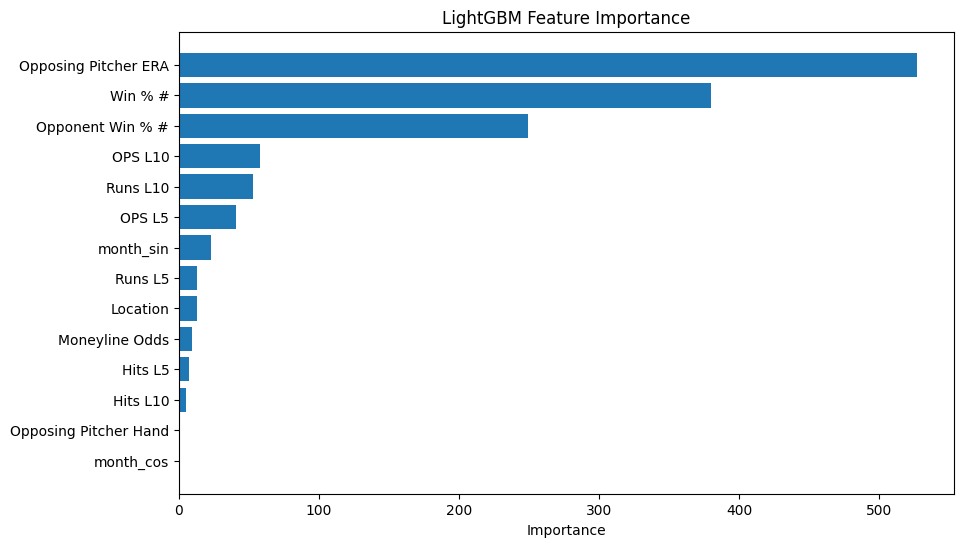

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance values
importances = final_lgb.feature_importances_

# Combine with feature names
feat_imp = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feat_imp)

# Optional: plot
plt.figure(figsize=(10,6))
plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("LightGBM Feature Importance")
plt.show()


In [22]:
feat_imp_gain = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": final_lgb.booster_.feature_importance(importance_type="gain")
}).sort_values(by="Importance", ascending=False)

print(feat_imp_gain.head(10))


                 Feature     Importance
4   Opposing Pitcher ERA  251237.696400
0                Win % #   83194.624514
3       Opponent Win % #   39684.336655
11               OPS L10    4819.670933
9               Runs L10    4529.846481
8                 OPS L5    3575.547695
12             month_sin    2075.664600
6                Runs L5    1354.513691
1               Location     874.697216
2         Moneyline Odds     781.440992


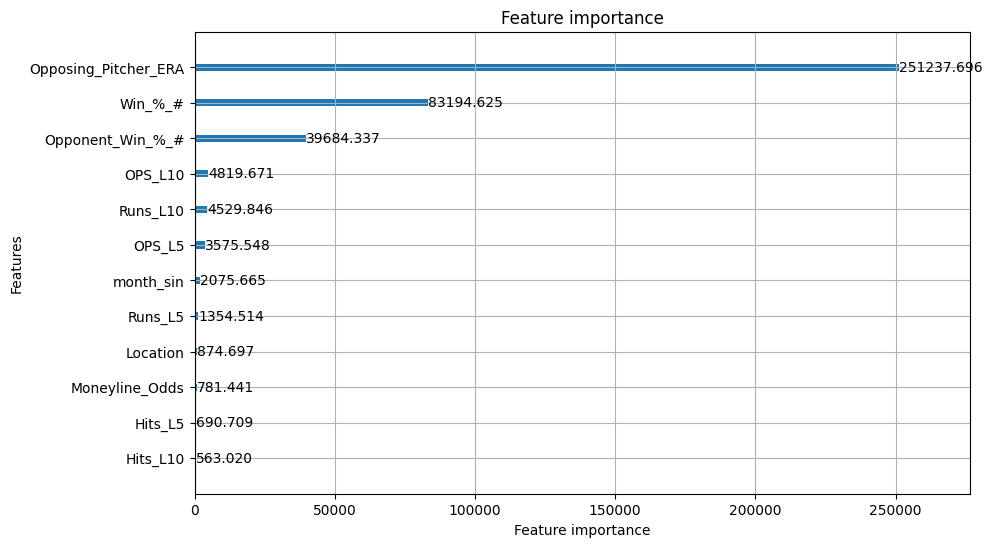

In [23]:
import lightgbm as lgb

lgb.plot_importance(final_lgb, importance_type="gain", max_num_features=15, figsize=(10,6))
plt.show()


## get data to predict(today)

In [32]:
# my_date = datetime(2025, 6, 14)

def get_test(date, df_clean):
    opposing_pitchers, games = get_pitchers(teams, date)
    # print(opposing_pitchers)
    # updated_pitchers, invalid_opp_pitchers = get_eras(opposing_pitchers, date)
    updated_pitchers = []
    invalid_opp_pitchers = []
    for p in opposing_pitchers:
        if p[7] == 'Nan':
            invalid_opp_pitchers.append(p[0])
        else:
            try:
                p[7] = float(p[7])        # try converting
            except ValueError:
                invalid_opp_pitchers.append(p[0])          # it cannot be a float
        updated_pitchers.append(p)
    print(f"invalid: {invalid_opp_pitchers}")
    print(f"updated pitchers before: {updated_pitchers}")
    updated_pitchers_2, invalid_opp_pitchers = get_eras(updated_pitchers, date)
    print(f"updated pitchers after: {updated_pitchers_2}")
    print(f"invalid: {invalid_opp_pitchers}")
    print("done")
    odds = fetch_mlbodds_for_date(date)
    print(odds)
    matchups, doubles, spreads = combine_pitchers_and_odds(updated_pitchers_2, odds)
    
    # print(f"date: {date}")
    # print(f"max date: {max(df_clean['Date'])}")
    day_ago_df = df_clean[df_clean['Date'] == (max(df_clean['Date']))]
    games = []
    for match in matchups:
        print(match)
        iter = 2
        while day_ago_df[day_ago_df['Team'] == match[0]].sort_values('Date', ascending=False).empty:
            print("got here")
            print(match)
            print(iter)
            day_ago_df = df_clean[df_clean['Date'] == (date - timedelta(days=iter))]
            iter += 1
            # continue
        match.append(float(day_ago_df[day_ago_df['Team'] == match[0]].sort_values('Date', ascending=False).iloc[0]['Next Runs L5']))
        match.append(float(day_ago_df[day_ago_df['Team'] == match[0]].sort_values('Date', ascending=False).iloc[0]['Next Runs L10']))
        match.append(float(day_ago_df[day_ago_df['Team'] == match[0]].sort_values('Date', ascending=False).iloc[0]['Next Hits L5']))
        match.append(float(day_ago_df[day_ago_df['Team'] == match[0]].sort_values('Date', ascending=False).iloc[0]['Next Hits L10']))
        match.append(float(day_ago_df[day_ago_df['Team'] == match[0]].sort_values('Date', ascending=False).iloc[0]['Next OPS L5']))
        match.append(float(day_ago_df[day_ago_df['Team'] == match[0]].sort_values('Date', ascending=False).iloc[0]['Next OPS L10']))
        match.append(date)
        # print(match)
    print(f"matchups: {len(matchups)}")

    desired_indices = [15, 0, 1, 2, 8, 3, 4, 7, 6, 9, 10, 11, 12, 13, 14]

    final_matchups = [[row[i] for i in desired_indices] for row in matchups]

    day_entries = pd.DataFrame(final_matchups, columns=['Date', 'Team', 'Win %', 'Location', 'Moneyline Odds', 'Opponent',
                                                    'Opponent Win %','Opposing Pitcher ERA', 'Opposing Pitcher Hand', 
                                                    'Runs L5', 'Runs L10', 'Hits L5', 'Hits L10', 'OPS L5', 'OPS L10'])

    print(f"day_entries: {len(day_entries)}")

    for i in range(len(day_entries)):

        me_lines = re.split(r"[-()]", day_entries.loc[i, 'Win %'])
        opp_lines = re.split(r"[-()]", day_entries.loc[i, 'Opponent Win %'])

        if len(me_lines) < 4:
            if len(opp_lines) < 4:
                continue
            else:
                opp_denom = float(opp_lines[1]) + float(opp_lines[2])

                if opp_denom == 0:
                    day_entries.loc[i,'Opponent Win % #'] = 0
                else:
                    day_entries.loc[i,'Opponent Win % #'] = round(float(opp_lines[1]) / opp_denom, 3)

        else:
            me_denom = float(me_lines[1]) + float(me_lines[2])

            if me_denom == 0:
                day_entries.loc[i,'Win % #'] = 0
            else:
                day_entries.loc[i,'Win % #'] = round(float(me_lines[1]) / me_denom, 3)

            if len(opp_lines) < 4:
                continue
            else:
                opp_denom = float(opp_lines[1]) + float(opp_lines[2])

                if opp_denom == 0:
                    day_entries.loc[i,'Opponent Win % #'] = 0
                else:
                    day_entries.loc[i,'Opponent Win % #'] = round(float(opp_lines[1]) / opp_denom, 3)

    for i in range(len(day_entries)):
        if day_entries.loc[i, 'Location'] == 'H':
            day_entries.loc[i, 'Location'] = 1
        elif day_entries.loc[i, 'Location'] == 'A':
            day_entries.loc[i, 'Location'] = 0

        if day_entries.loc[i, 'Opposing Pitcher Hand'] == 'LHP':
            day_entries.loc[i, 'Opposing Pitcher Hand'] = 1
        elif day_entries.loc[i, 'Opposing Pitcher Hand'] == 'RHP':
            day_entries.loc[i, 'Opposing Pitcher Hand'] = 0
        elif day_entries.loc[i, 'Opposing Pitcher Hand'] == '右投手':
            day_entries.loc[i, 'Opposing Pitcher Hand'] = 0
        elif day_entries.loc[i, 'Opposing Pitcher Hand'] == '左投手':
            day_entries.loc[i, 'Opposing Pitcher Hand'] = 1
        elif day_entries.loc[i, 'Opposing Pitcher Hand'] == 'LD':
            day_entries.loc[i, 'Opposing Pitcher Hand'] = 0
        elif day_entries.loc[i, 'Opposing Pitcher Hand'] == 'LZ':
            day_entries.loc[i, 'Opposing Pitcher Hand'] = 1
        else:
            day_entries.loc[i, 'Opposing Pitcher Hand'] = 0
        

    numeric_cols = [
        'Win % #',
        # 'Score',
        'Moneyline Odds',
        'Opponent Win % #',
        'Opposing Pitcher ERA',
        'Runs L5',
        'Hits L5',
        'OPS L5',
        'Runs L10',
        'Hits L10',
        'OPS L10'
    ]

    int_cols = ['Location', 'Moneyline Odds', 'Opposing Pitcher Hand',]
    float_cols = ['Win % #', 'Opponent Win % #', 'Opposing Pitcher ERA', 'Runs L5',
                    'Hits L5', 'OPS L5', 'Runs L10', 'Hits L10', 'OPS L10']

    print(f"day_entries: {len(day_entries)}")

    df_clean = day_entries.dropna(subset=numeric_cols).copy()
    df_clean.reset_index(drop=True, inplace=True)

    print(f"df_clean: {len(df_clean)}")

    df_clean[int_cols] = df_clean[int_cols].astype(int)
    df_clean[float_cols] = df_clean[float_cols].astype(float)

    df_clean['Date'] = pd.to_datetime(df_clean['Date'])


    df_clean['month_sin']  = np.sin(2 * np.pi * df_clean['Date'].dt.month  / 12)
    df_clean['month_cos']  = np.cos(2 * np.pi * df_clean['Date'].dt.month  / 12)

    games = df_clean['Team'].values


    keep_cols_day = ['Win % #', 'Location', 'Moneyline Odds', 'Opponent Win % #',
                'Opposing Pitcher ERA', 'Opposing Pitcher Hand', 'Runs L5', 'Hits L5',
                'OPS L5', 'Runs L10', 'Hits L10', 'OPS L10', 'month_sin', 'month_cos']
    df_red = df_clean[keep_cols_day]

    return df_red, games, invalid_opp_pitchers, spreads


day_df, games, invalid_opp_pitchers, spreads = get_test(date_to_predict, df_clean)
day_df


Jackie rob
Jackie rob
Jackie rob
Jackie rob
Jackie rob
Jackie rob
Jackie rob
Jackie rob
Jackie rob
Jackie rob
Jackie rob
Jackie rob
Jackie rob
Jackie rob
invalid: ['Rockies']
updated pitchers before: [['Nationals', '(8-9)', 'A', 'Pirates', '(10-7)', 'Mason Montgomery', 'LHP', 5.4], ['Pirates', '(10-7)', 'H', 'Nationals', '(8-9)', 'Jake Irvin', 'RHP', 6.16], ['Cubs', '(8-9)', 'A', 'Phillies', '(8-9)', 'Jesús Luzardo', 'LHP', 6.45], ['Phillies', '(8-9)', 'H', 'Cubs', '(8-9)', 'Shota Imanaga', 'LHP', 2.7], ['Royals', '(7-10)', 'A', 'Tigers', '(8-9)', 'Jack Flaherty', 'RHP', 4.19], ['Tigers', '(8-9)', 'H', 'Royals', '(7-10)', 'Seth Lugo', 'RHP', 1.59], ['Giants', '(6-11)', 'A', 'Reds', '(10-7)', 'Rhett Lowder', 'RHP', 3.38], ['Reds', '(10-7)', 'H', 'Giants', '(6-11)', 'Tyler Mahle', 'RHP', 7.23], ['Angels', '(9-9)', 'A', 'Yankees', '(9-8)', 'Luis Gil', 'RHP', 4.7], ['Yankees', '(9-8)', 'H', 'Angels', '(9-9)', 'Jack Kochanowicz', 'RHP', 4.12], ['Marlins', '(9-9)', 'A', 'Braves', '(11-7)', '

,Win % #,Location,Moneyline Odds,Opponent Win % #,Opposing Pitcher ERA,Opposing Pitcher Hand,Runs L5,Hits L5,OPS L5,Runs L10,Hits L10,OPS L10,month_sin,month_cos
0,0.471,0,144,0.588,5.40,1,4.4,8.6,0.7008,4.4,9.0,0.7005,0.866025,-0.5
1,0.588,1,-175,0.471,6.16,0,7.8,11.2,0.8854,5.5,8.3,0.7441,0.866025,-0.5
2,0.471,0,117,0.471,6.45,1,6.4,11.4,0.8704,6.5,10.6,0.8602,0.866025,-0.5
3,0.471,1,-141,0.471,2.70,1,6.2,10.4,0.8028,4.4,9.1,0.7128,0.866025,-0.5
4,0.412,0,114,0.471,4.19,0,2.0,5.0,0.4890,4.0,6.7,0.5659,0.866025,-0.5
5,0.471,1,-137,0.412,1.59,0,4.6,7.2,0.6506,4.4,7.2,0.6273,0.866025,-0.5
6,0.353,0,-112,0.588,3.38,0,5.0,8.8,0.7386,4.8,8.6,0.7429,0.866025,-0.5
7,0.588,1,-108,0.353,7.23,0,5.0,5.8,0.5904,5.7,6.7,0.6417,0.866025,-0.5
8,0.500,0,157,0.529,4.70,0,5.4,10.6,0.8770,5.2,9.8,0.7960,0.866025,-0.5
9,0.529,1,-192,0.500,4.12,0,5.2,9.6,0.8616,4.7,8.4,0.7775,0.866025,-0.5


In [ ]:
# day_df.loc[0, 'Opposing Pitcher ERA'] = 
# day_df.loc[1, 'Opposing Pitcher ERA'] = 7.07
# day_df.loc[2, 'Opposing Pitcher ERA'] = 6.23
# day_df.loc[3, 'Opposing Pitcher ERA'] = 2.81
# day_df.loc[4, 'Opposing Pitcher ERA'] = 5.14
# day_df.loc[5, 'Opposing Pitcher ERA'] = 1.53
# day_df.loc[6, 'Opposing Pitcher ERA'] = 3.31
# day_df.loc[7, 'Opposing Pitcher ERA'] = 4.30
# day_df.loc[8, 'Opposing Pitcher ERA'] = 6.75
# day_df.loc[9, 'Opposing Pitcher ERA'] = 3.24
# day_df.loc[10, 'Opposing Pitcher ERA'] = 1.02
# day_df.loc[11, 'Opposing Pitcher ERA'] = 6.14
# day_df.loc[12, 'Opposing Pitcher ERA'] = 0.73
# day_df.loc[13, 'Opposing Pitcher ERA'] = 2.45
# day_df.loc[14, 'Opposing Pitcher ERA'] = 3.60
# day_df.loc[15, 'Opposing Pitcher ERA'] = 
# day_df.loc[16, 'Opposing Pitcher ERA'] = 
# day_df.loc[24, 'Opposing Pitcher ERA'] = 5.27
# day_df.loc[25, 'Opposing Pitcher ERA'] = 0.50
# day_df.loc[26, 'Opposing Pitcher ERA'] = 9.45
# day_df.loc[27, 'Opposing Pitcher ERA'] = 5.74
# day_df.loc[28, 'Opposing Pitcher ERA'] = 4.60
# day_df.loc[29, 'Opposing Pitcher ERA'] = 2.63

# day_df['Win % #'] = 0
# day_df['Opponent Win % #'] = 0

day_df

,Win % #,Location,Moneyline Odds,Opponent Win % #,Opposing Pitcher ERA,Opposing Pitcher Hand,Runs L5,Hits L5,OPS L5,Runs L10,Hits L10,OPS L10,month_sin,month_cos
0,0.471,0,144,0.588,5.40,1,4.4,8.6,0.7008,4.4,9.0,0.7005,0.866025,-0.5
1,0.588,1,-175,0.471,7.07,0,7.8,11.2,0.8854,5.5,8.3,0.7441,0.866025,-0.5
2,0.471,0,117,0.471,6.23,1,6.4,11.4,0.8704,6.5,10.6,0.8602,0.866025,-0.5
3,0.471,1,-141,0.471,2.81,1,6.2,10.4,0.8028,4.4,9.1,0.7128,0.866025,-0.5
4,0.412,0,114,0.471,5.14,0,2.0,5.0,0.4890,4.0,6.7,0.5659,0.866025,-0.5
5,0.471,1,-137,0.412,1.53,0,4.6,7.2,0.6506,4.4,7.2,0.6273,0.866025,-0.5
6,0.353,0,-112,0.588,3.31,0,5.0,8.8,0.7386,4.8,8.6,0.7429,0.866025,-0.5
7,0.588,1,-108,0.353,4.30,0,5.0,5.8,0.5904,5.7,6.7,0.6417,0.866025,-0.5
8,0.500,0,157,0.529,6.75,0,5.4,10.6,0.8770,5.2,9.8,0.7960,0.866025,-0.5
9,0.529,1,-192,0.500,3.24,0,5.2,9.6,0.8616,4.7,8.4,0.7775,0.866025,-0.5


In [34]:
games

array(['Nationals', 'Pirates', 'Cubs', 'Phillies', 'Royals', 'Tigers',
       'Giants', 'Reds', 'Angels', 'Yankees', 'Marlins', 'Braves',
       'Blue Jays', 'Brewers', 'Rays', 'White Sox', 'Rockies', 'Astros',
       'Mariners', 'Padres', 'Rangers', 'Athletics', 'Mets', 'Dodgers',
       'Diamondbacks', 'Orioles', 'Guardians', 'Cardinals', 'Red Sox',
       'Twins'], dtype=object)

In [35]:

X_new = day_df

y_pred_new = final_lgb.predict(X_new)
print(len(games))
print(date_to_predict.strftime("%m-%d-%y"))
game_indicator = 0
for i in range(len(games)-1):
    if game_indicator == 0:
        game_indicator = 1
        print(f"Game: {games[i]} vs {games[i+1]}")
        print(f"\t{round(y_pred_new[i].item(), 3)} to {round(y_pred_new[i+1].item(), 3)}")
    else:
        game_indicator = 0


[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
30
04-15-26
Game: Nationals vs Pirates
	4.757 to 6.255
Game: Cubs vs Phillies
	5.116 to 3.54
Game: Royals vs Tigers
	4.65 to 3.438
Game: Giants vs Reds
	3.623 to 5.289
Game: Angels vs Yankees
	5.863 to 4.064
Game: Marlins vs Braves
	3.251 to 5.684
Game: Blue Jays vs Brewers
	3.409 to 3.778
Game: Rays vs White Sox
	4.534 to 3.085
Game: Rockies vs Astros
	4.852 to 4.441
Game: Mariners vs Padres
	3.19 to 4.173
Game: Rangers vs Athletics
	4.027 to 4.772
Game: Mets vs Dodgers
	2.974 to 4.409
Game: Diamondbacks vs Orioles
	5.224 to 3.295
Game: Guardians vs Cardinals
	6.09 to 5.452
Game: Red Sox vs Twins
	4.249 to 3.968


In [36]:
df_clean.size

336912

In [37]:
# pick_a_date = datetime(2025, 6, 19)
# pick_a_day_df = df_clean[df_clean['Date'] == pick_a_date]
# pick_a_day_df


### predict wins

In [38]:
use_data_date = date_to_add
copy_df = pd.read_csv(f"daily_entries/daily_entries_{use_data_date.strftime("%y_%m_%d")}.csv")

In [39]:
copied = copy_df.sort_values(['Team', 'Date'])

# 3) Compute L5 and L10 by grouping on Team:
copied['Runs L5'] = (
    copied
    .groupby('Team')['Runs']
    .transform(lambda x: x.shift(1)                # exclude current game
                    .rolling(window=5,
                                min_periods=1)     # use fewer games if < 5 exist
                    .mean())
)

copied['Hits L5'] = (
    copied
    .groupby('Team')['Hits']
    .transform(lambda x: x.shift(1)                # exclude current game
                    .rolling(window=5,
                                min_periods=1)     # use fewer games if < 5 exist
                    .mean())
)

copied['OPS L5'] = (
    copied
    .groupby('Team')['OPS']
    .transform(lambda x: x.shift(1)                # exclude current game
                    .rolling(window=5,
                                min_periods=1)     # use fewer games if < 5 exist
                    .mean())
)


copied['Runs L10'] = (
    copied
    .groupby('Team')['Runs']
    .transform(lambda x: x.shift(1)
                    .rolling(window=10,
                                min_periods=1)
                    .mean())
)

copied['Hits L10'] = (
    copied
    .groupby('Team')['Hits']
    .transform(lambda x: x.shift(1)
                    .rolling(window=10,
                                min_periods=1)
                    .mean())
)

copied['OPS L10'] = (
    copied
    .groupby('Team')['OPS']
    .transform(lambda x: x.shift(1)
                    .rolling(window=10,
                                min_periods=1)
                    .mean())
)

# 3) Compute L5 and L10 by grouping on Team:
copied['Next Runs L5'] = (
    copied
    .groupby('Team')['Runs']
    .transform(lambda x: x.shift(0)                # exclude current game
                    .rolling(window=5,
                                min_periods=1)     # use fewer games if < 5 exist
                    .mean())
)

copied['Next Hits L5'] = (
    copied
    .groupby('Team')['Hits']
    .transform(lambda x: x.shift(0)                # exclude current game
                    .rolling(window=5,
                                min_periods=1)     # use fewer games if < 5 exist
                    .mean())
)

copied['Next OPS L5'] = (
    copied
    .groupby('Team')['OPS']
    .transform(lambda x: x.shift(0)                # exclude current game
                    .rolling(window=5,
                                min_periods=1)     # use fewer games if < 5 exist
                    .mean())
)


copied['Next Runs L10'] = (
    copied
    .groupby('Team')['Runs']
    .transform(lambda x: x.shift(0)
                    .rolling(window=10,
                                min_periods=1)
                    .mean())
)

copied['Next Hits L10'] = (
    copied
    .groupby('Team')['Hits']
    .transform(lambda x: x.shift(0)
                    .rolling(window=10,
                                min_periods=1)
                    .mean())
)

copied['Next OPS L10'] = (
    copied
    .groupby('Team')['OPS']
    .transform(lambda x: x.shift(0)
                    .rolling(window=10,
                                min_periods=1)
                    .mean())
)


df = copied[['Date', 'Team', 'Win % #', 'Score', 'Location', 'Moneyline Odds',
        'Opponent', 'Opponent Win % #',
        'Opposing Pitcher ERA', 'Opposing Pitcher Hand',
        'Runs L5', 'Hits L5', 'OPS L5',
        'Runs L10', 'Hits L10', 'OPS L10',
        'Next Runs L5', 'Next Runs L10', 'Next Hits L5',
        'Next Hits L10', 'Next OPS L5', 'Next OPS L10']]
df

numeric_cols = [
    'Win % #',
    'Score',
    'Moneyline Odds',
    'Opponent Win % #',
    'Opposing Pitcher ERA',
    'Runs L5',
    'Hits L5',
    'OPS L5',
    'Runs L10',
    'Hits L10',
    'OPS L10',
    'Next Runs L5', 'Next Runs L10', 'Next Hits L5',
    'Next Hits L10', 'Next OPS L5', 'Next OPS L10'
]

int_cols = ['Score', 'Location', 'Moneyline Odds', 'Opposing Pitcher Hand',]
float_cols = ['Win % #', 'Opponent Win % #', 'Opposing Pitcher ERA', 'Runs L5',
                'Hits L5', 'OPS L5', 'Runs L10', 'Hits L10', 'OPS L10',
                'Next Runs L5', 'Next Runs L10', 'Next Hits L5',
                'Next Hits L10', 'Next OPS L5', 'Next OPS L10']

df_clean = df.dropna(subset=numeric_cols).copy()
df_clean.reset_index(drop=True, inplace=True)

df_clean[int_cols] = df_clean[int_cols].astype(int)
df_clean[float_cols] = df_clean[float_cols].astype(float)

df_clean['Date'] = pd.to_datetime(df_clean['Date'])


df_clean['month_sin']  = np.sin(2 * np.pi * df_clean['Date'].dt.month  / 12)
df_clean['month_cos']  = np.cos(2 * np.pi * df_clean['Date'].dt.month  / 12)



In [40]:
df_map = (
    df_clean[['Date','Team','Score']]
    .rename(columns={
        'Team':'Opponent',
        'Score':'Opponent Score'
    })
)

df_wins = df_clean.merge(
    df_map,
    on=['Date','Opponent'],
    how='left'
)

df_wins["Win"] = (df_wins["Score"] > df_wins["Opponent Score"]).astype(int)

In [41]:
df_wins_red = pd.get_dummies(
    df_wins,
    columns=['Team', 'Opponent'],
    prefix=['Team', 'Opp'],
    drop_first=True
)

keep_cols_win = ['Win % #', 'Score', 'Win', 'Location', 'Moneyline Odds', 'Opponent Win % #',
            'Opposing Pitcher ERA', 'Opposing Pitcher Hand', 'Runs L5', 'Hits L5',
            'OPS L5', 'Runs L10', 'Hits L10', 'OPS L10', 'month_sin', 'month_cos']
df_wins_red = df_wins_red[keep_cols_win]
df_wins_red.size
len(df_wins_red)


14398

In [42]:
X_win = df_wins_red.drop(columns=['Score', 'Win'])

y_win = df_wins_red["Win"]

X_train_win, X_test_win, y_train_win, y_test_win = train_test_split(
    X_win, y_win, test_size=0.20, random_state=42, stratify=y_win
)


In [43]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import make_scorer, roc_auc_score
import numpy as np


In [44]:
best_params_win =  {'bagging_fraction': 0.6, 'bagging_freq': 0, 'feature_fraction': 0.6, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 31}

# best_params_win = {'bagging_fraction': 0.4, 'bagging_freq': 0, 'feature_fraction': 0.4, 'learning_rate': 0.005, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 31}

final_win_lgb = LGBMClassifier(**best_params_win)

final_win_lgb.fit(X_train_win, y_train_win)

[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0
[LightGBM] [Info] Number of positive: 5739, number of negative: 5779
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000317 seconds.
You can set `force_col_wise=true` to remove the o

LGBMClassifier(bagging_fraction=0.6, bagging_freq=0, feature_fraction=0.6,
               learning_rate=0.01, max_depth=5)

                  Feature  Importance
0                 Win % #         542
3        Opponent Win % #         453
4    Opposing Pitcher ERA         424
2          Moneyline Odds         262
10               Hits L10         250
11                OPS L10         203
9                Runs L10         186
8                  OPS L5         165
1                Location         112
6                 Runs L5         108
7                 Hits L5          95
12              month_sin          40
13              month_cos          31
5   Opposing Pitcher Hand           9


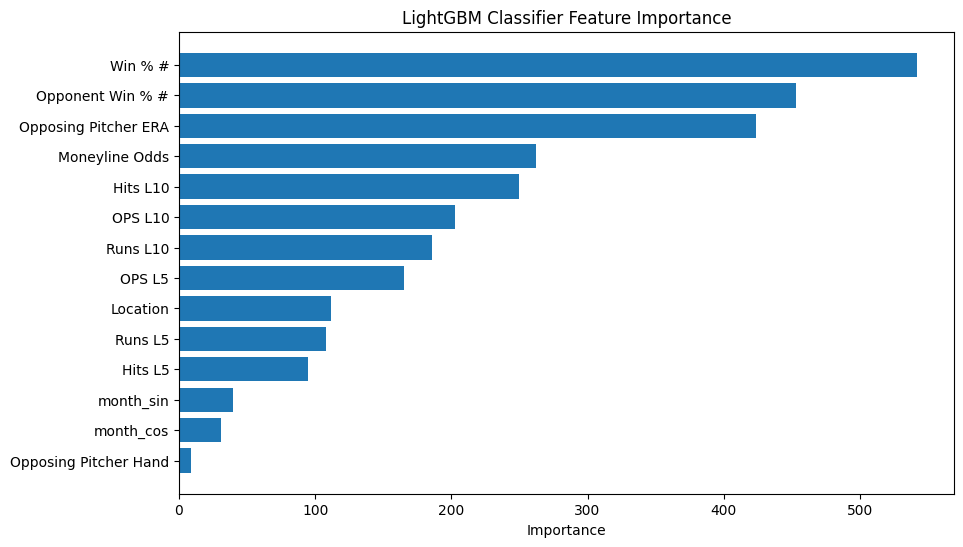

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances
importances = final_win_lgb.feature_importances_

# Combine with feature names
feat_imp = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feat_imp.head(15))

# Plot
plt.figure(figsize=(10,6))
plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("LightGBM Classifier Feature Importance")
plt.show()


In [46]:
feat_imp_gain = pd.DataFrame({
    "Feature": X_train.columns,
    "GainImportance": final_win_lgb.booster_.feature_importance(importance_type="gain"),
    "SplitImportance": final_win_lgb.booster_.feature_importance(importance_type="split")
}).sort_values(by="GainImportance", ascending=False)

print(feat_imp_gain.head(10))


                 Feature  GainImportance  SplitImportance
0                Win % #    17602.415624              542
3       Opponent Win % #    14489.072827              453
4   Opposing Pitcher ERA     6482.565300              424
2         Moneyline Odds     3805.083410              262
10              Hits L10     1495.920500              250
1               Location     1068.320983              112
11               OPS L10     1043.644538              203
9               Runs L10      990.705536              186
8                 OPS L5      813.521095              165
6                Runs L5      479.312518              108


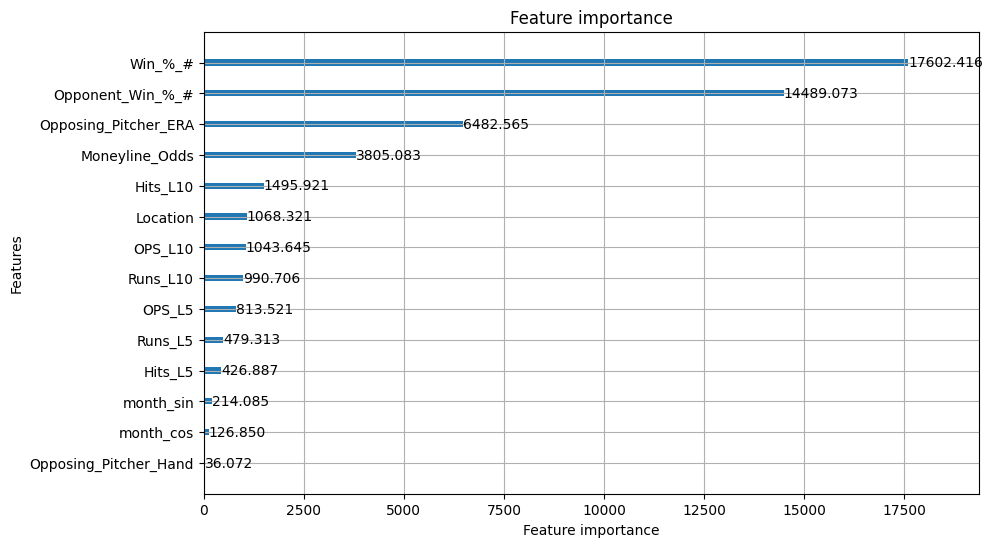

In [47]:
import lightgbm as lgb

lgb.plot_importance(final_win_lgb, importance_type="gain", max_num_features=15, figsize=(10,6))
plt.show()


In [48]:
# pred_date = datetime(2025, 7, 1)
pred_date = date_to_predict
day_df_win, games_win, invalid_opps, spreads = get_test(pred_date, df_clean)
# day_df_win

Jackie rob
Jackie rob
Jackie rob
Jackie rob
Jackie rob
Jackie rob
Jackie rob
Jackie rob
Jackie rob
Jackie rob
Jackie rob
Jackie rob
Jackie rob
Jackie rob
invalid: []
updated pitchers before: [['Marlins', '(9-9)', 'A', 'Braves', '(11-7)', 'Bryce Elder', 'RHP', 0.77], ['Braves', '(11-7)', 'H', 'Marlins', '(9-9)', 'Chris Paddack', 'RHP', 5.59], ['Blue Jays', '(7-9)', 'A', 'Brewers', '(8-8)', 'Chad Patrick', 'RHP', 0.95], ['Brewers', '(8-8)', 'H', 'Blue Jays', '(7-9)', 'Dylan Cease', 'RHP', 1.74], ['Rays', '(9-7)', 'A', 'White Sox', '(6-11)', 'Sean Burke', 'RHP', 4.43], ['White Sox', '(6-11)', 'H', 'Rays', '(9-7)', 'Jesse Scholtens', 'RHP', 0.0], ['Rockies', '(6-11)', 'A', 'Astros', '(7-11)', 'Spencer Arrighetti', 'RHP', 1.8], ['Astros', '(7-11)', 'H', 'Rockies', '(6-11)', 'Jose Quintana', 'LHP', 5.63], ['Mariners', '(8-10)', 'A', 'Padres', '(11-6)', 'Randy Vásquez', 'RHP', 0.96], ['Padres', '(11-6)', 'H', 'Mariners', '(8-10)', 'Emerson Hancock', 'RHP', 1.93], ['Rangers', '(9-8)', 'A', 'At

In [49]:
# day_df_win.loc[0, 'Opposing Pitcher ERA'] = 3.65
# day_df_win.loc[1, 'Opposing Pitcher ERA'] = 2.96
# day_df_win.loc[2, 'Opposing Pitcher ERA'] = 3.59
# day_df_win.loc[3, 'Opposing Pitcher ERA'] = 4.54
# day_df_win.loc[4, 'Opposing Pitcher ERA'] = 5.36
# day_df_win.loc[5, 'Opposing Pitcher ERA'] = 4.98
# day_df_win.loc[6, 'Opposing Pitcher ERA'] = 2.58
# day_df_win.loc[7, 'Opposing Pitcher ERA'] = 4.67
# day_df_win.loc[8, 'Opposing Pitcher ERA'] = 3.94
# day_df_win.loc[9, 'Opposing Pitcher ERA'] = 3.99
# day_df_win.loc[10, 'Opposing Pitcher ERA'] = 3.44
# day_df_win.loc[11, 'Opposing Pitcher ERA'] = 3.66
# day_df_win.loc[12, 'Opposing Pitcher ERA'] = 4.21
# day_df_win.loc[13, 'Opposing Pitcher ERA'] = 3.06
# day_df_win.loc[14, 'Opposing Pitcher ERA'] = 2.82
# day_df_win.loc[15, 'Opposing Pitcher ERA'] = 3.39
# day_df.loc[16, 'Opposing Pitcher ERA'] = 2.50
# day_df.loc[17, 'Opposing Pitcher ERA'] = 1.73
# day_df.loc[18, 'Opposing Pitcher ERA'] = 2.49
# day_df.loc[19, 'Opposing Pitcher ERA'] = 4.83
# day_df.loc[20, 'Opposing Pitcher ERA'] = 3.44
# day_df.loc[21, 'Opposing Pitcher ERA'] = 4.24

# day_df_win['Win % #'] = 0
# day_df_win['Opponent Win % #'] = 0

## score diff based on odds

In [50]:
import math
from math import exp, factorial, sqrt
from mpmath import besseli

# Poisson CDF: P(T <= k)
def pois_cdf(k, lam):
    return exp(-lam) * sum(lam**i / factorial(i) for i in range(k+1))

def infer_S_from_total(total_line, p_over, p_under):
    # map "Over x.5" -> P(T >= ceil(x.5)) = p_over
    k = math.floor(total_line) + 1  # e.g., 7.5 -> k=8

    # binary search for S
    lo, hi = 0.1, 20.0
    for _ in range(60):
        mid = (lo + hi) / 2
        p_tail = 1 - pois_cdf(k-1, mid)  # P(T >= k)
        if p_tail < p_over:
            lo = mid
        else:
            hi = mid
    return 0.5 * (lo + hi)

def skellam_pmf(k, l1, l2):
    return exp(-(l1+l2)) * (l1/l2)**(k/2) * float(besseli(abs(k), 2*sqrt(l1*l2)))

def P_D_gt_0(mu, S):
    l1, l2 = (S+mu)/2, (S-mu)/2
    s, k = 0.0, 1
    while True:
        t = skellam_pmf(k, l1, l2)
        s += t
        if t < 1e-12 and k > 50: break
        k += 1
    return s

def devig_odds(odds1, odds2):
    odds1_num = int(odds1)
    odds1_exp = -odds1_num / (-odds1_num+100) if odds1_num < 0 else 100/(odds1_num+100)
    odds2_num = int(odds2)
    odds2_exp = -odds2_num / (-odds2_num+100) if odds2_num < 0 else 100/(odds2_num+100)

    odds1_revig = round(odds1_exp / (odds1_exp+odds2_exp), 3)
    odds2_revig = round(odds2_exp / (odds1_exp+odds2_exp), 3)

    return odds1_revig, odds2_revig

def expected_scores(away_odds, home_odds):
    # 0: team
    # 1: ml
    # 2: spread
    # 3: spread odds
    # 4: total line
    # 5: over total odds
    # 6: under total odds

    away_devig, home_devig = devig_odds(away_odds[1], home_odds[1])
    fav_devig = away_devig if away_devig > home_devig else home_devig

    over_devig, under_devig = devig_odds(away_odds[5], away_odds[6])

    S = infer_S_from_total(float(away_odds[4]), over_devig, under_devig)

    lo, hi = -S + 1e-6, S - 1e-6        # mu bounds
    for _ in range(60):                  # bisection on mu
        mid = (lo + hi) / 2
        if P_D_gt_0(mid, S) < fav_devig:
            lo = mid
        else:
            hi = mid
    mu = (lo + hi) / 2

    if fav_devig == away_devig:
        return round((S + mu)/2, 3), round((S - mu)/2, 3), round(mu, 3)
    elif fav_devig == home_devig:
        return round((S - mu)/2, 3), round((S + mu)/2, 3), round(-mu, 3)

# predictions

### score and wins

In [51]:

X_new = day_df

y_pred_new = final_lgb.predict(X_new)
print(len(games))
print(date_to_predict.strftime("%m-%d-%y"))
for i in range(0, len(games)-1, 2):
    away = games[i]
    home = games[i+1]
    away_pred = round(y_pred_new[i].item(), 3)
    home_pred = round(y_pred_new[i+1].item(), 3)
    # print(f"Game: {away} @ {home}")
    # print(f"\t{away_pred} to {home_pred}")
    away_spread = spreads[i]
    home_spread = spreads[i+1]

    winner = home if home_pred >= away_pred else away
    # hm, am = _ml_lookup.get((home, away), (None, None))
    # ml = hm if winner == home else am
    if away in invalid_opp_pitchers or home in invalid_opp_pitchers:
        print(f"Pitchers TBD ")
    if winner == home:
        # print(f"Winner: {winner}, Score: {away_pred} to {home_pred} (ML: {day_df['Moneyline Odds'][i+1]})")
        print(f"Game: {away} @ {home}, {away_pred} to {home_pred} (ML: {day_df['Moneyline Odds'][i+1]})")
    elif winner == away:
        # print(f"Winner: {winner}, Score: {away_pred} to {home_pred} (ML: {day_df['Moneyline Odds'][i]})")
        print(f"Game: {away} @ {home}, {away_pred} to {home_pred} (ML: {day_df['Moneyline Odds'][i]})")
    else:
        print(f"Winner: {winner} (ML: N/A)")
    
    print(expected_scores(away_spread, home_spread))
    # print(home_spread)
    print("__________________")




[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
30
04-15-26
Game: Nationals @ Pirates, 4.757 to 6.255 (ML: -175)
(4.173, 5.41, -1.237)
__________________
Game: Cubs @ Phillies, 5.116 to 3.54 (ML: 117)
(4.258, 3.515, 0.743)
__________________
Game: Royals @ Tigers, 4.65 to 3.438 (ML: 114)
(4.542, 4.002, 0.54)
__________________
Game: Giants @ Reds, 3.623 to 5.289 (ML: -108)
(3.661, 5.179, -1.518)
__________________
Game: Angels @ Yankees, 5.863 to 4.064 (ML: 157)
(4.542, 4.002, 0.54)
__________________
Game: Marlins @ Braves, 3.251 to 5.684 (ML: -163)
(4.97, 5.601, -0.631)
__________________
Game: Blue Jays @ Brewers, 3.409 to 3.778 (ML: 105)
(3.044, 4.508, -1.465)
__________________
Game: R

In [52]:
X_new_win = day_df_win

y_pred_new_win = final_win_lgb.predict(X_new_win)
y_proba_win = final_win_lgb.predict_proba(X_new_win)
print(pred_date.strftime("%m-%d-%y"))
for i in range(0, len(games_win)-1, 2):
    away_win = games_win[i]
    home_win = games_win[i+1]
    away_prob = (y_proba_win[i][1] + y_proba_win[i+1][0]) / 2
    home_prob = (y_proba_win[i][0] + y_proba_win[i+1][1]) / 2
    # print(f"Game: {away_win} @ {home_win}")
    # team1_prob = (y_proba_win[i][1] + y_proba_win[i+1][0]) / 2
    # team2_prob = (y_proba_win[i][0] + y_proba_win[i+1][1]) / 2
    if away_prob > home_prob:
        print(f"Winner: {away_win}, Conf: {round(away_prob*100, 2)} (ML: {day_df_win['Moneyline Odds'][i]})")
    elif away_prob < home_prob:
        print(f"Winner: {home_win}, Conf: {round(home_prob*100, 2)} (ML: {day_df_win['Moneyline Odds'][i+1]})")
    else:
        print("uhoh")
    print("__________________")


[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0
[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0
04-15-26
Winner: Braves, Conf: 55.06 (ML: -163)
__________________
Winner: Brewers, Conf: 54.44 (ML: 105)
__________________
Winner: Rays, Conf: 60.09 (ML: -112)
__________________
Winner: Astros, Conf: 56.71 (ML: -196)
__________________
Winner: Padres, Conf: 58.04 (ML: -108)
__________________
Winne

## all predictions

In [53]:
from termcolor import colored
# run predictions: y_pred_new
# win predictions: y_proba_win
bets = []
errors = []
this_date = pred_date.strftime("%m-%d-%y")
print(this_date)
print(f"{int(len(games)/2)} games")
for i in range(0, len(games)-1, 2):
    # teams
    away = games[i]
    home = games[i+1]

    ## odds
    # 0: team
    # 1: ml
    # 2: spread
    # 3: spread odds
    # 4: total line
    # 5: over total odds
    # 6: under total odds
    away_spread = spreads[i]
    home_spread = spreads[i+1]

    # score predictions
    away_score_pred = round(y_pred_new[i].item(), 3)
    home_score_pred = round(y_pred_new[i+1].item(), 3)

    # win probability predictions
    away_win_prob = round(((y_proba_win[i][1] + y_proba_win[i+1][0]) / 2) * 100, 1)
    home_win_prob = round(((y_proba_win[i][0] + y_proba_win[i+1][1]) / 2)  * 100, 1)

    # expected scores
    away_exp_score, home_exp_score, exp_score_diff = expected_scores(away_spread, home_spread)

    # expected win probability
    away_exp_win, home_exp_win = devig_odds(away_spread[1], home_spread[1])
    away_exp_win = round(away_exp_win * 100, 3)
    home_exp_win = round(home_exp_win * 100, 3)

    # calc diffs and totals
    predicted_diff = round(away_score_pred-home_score_pred, 3)
    # exp_diff = round(away_exp_score-home_exp_score, 3)
    predicted_total = round(away_score_pred+home_score_pred, 3)
    exp_total = round(away_exp_score+home_exp_score, 3)
    #{colored(era[1], 'green')}
    print(f"\t\t{away} @ {home}")
    if away in invalid_opp_pitchers or home in invalid_opp_pitchers:
        errors.append([away, home, "tbd"])
        # print(f"Pitchers TBD ")
        # print("________________________________________________________________________________")
        # continue

    print(f"predicted scores:\t\t{away_score_pred} to {home_score_pred}")
    print(f"exp scores:\t\t\t{away_exp_score} to {home_exp_score}")
    # # diffs
    # if abs(predicted_diff) > abs(exp_score_diff):
    #     print(f"predicted vs exp diff:\t\t{predicted_diff} vs {exp_score_diff}\t\t{colored(away if predicted_diff > 0  else home, 'green')} {colored(away_spread[1] if predicted_diff > 0  else home_spread[1], 'green')} {round(predicted_diff - exp_score_diff, 3)}")
    #     bets.append([this_date, away, home, away if predicted_diff > 0  else home, away_spread[1] if predicted_diff > 0  else home_spread[1], abs(predicted_diff), abs(round(predicted_diff - exp_score_diff, 3)), '', '', '', ''])
    # else:
    #     print(f"predicted vs exp diff:\t\t{predicted_diff} vs {exp_score_diff}")
    
    # # win probs
    # if away_win_prob > home_win_prob: # away predicted to win
    #     print(f"\t\t\t{away} win")
    #     if away_win_prob > away_exp_win:
    #         print(f"predicted vs exp win %:\t\t{away_win_prob} % vs {away_exp_win} %\t{colored(away, 'green')} {colored(away_spread[1], 'green')} {round(away_win_prob - away_exp_win, 3)} %")
    #         if len(bets) >= 1:
    #             if bets[-1][1:4] == [away, home, away]:
    #                 bets[-1][7] = away_win_prob
    #                 bets[-1][8] = round(away_win_prob - away_exp_win, 3)
    #             else:
    #                 bets.append([this_date, away, home, away, away_spread[1], '', '', away_win_prob, round(away_win_prob - away_exp_win, 3), '', ''])
    #         else:
    #             bets.append([this_date, away, home, away, away_spread[1], '', '', away_win_prob, round(away_win_prob - away_exp_win, 3), '', ''])
    #     else:
    #         print(f"predicted vs exp win %:\t\t{away_win_prob} % vs {away_exp_win} %")
    # elif away_win_prob < home_win_prob: # home team predicted to win
    #     print(f"\t\t\t{home} win")
    #     if home_win_prob > home_exp_win:
    #         print(f"predicted vs exp win %:\t\t{home_win_prob} % vs {home_exp_win} %\t{colored(home, 'green')} {colored(home_spread[1], 'green')} {round(home_win_prob - home_exp_win, 3)} %")
    #         if len(bets) >= 1:
    #             if bets[-1][1:4] == [away, home, home]:
    #                 bets[-1][7] = home_win_prob
    #                 bets[-1][8] = round(home_win_prob - home_exp_win, 3)
    #             else:
    #                 bets.append([this_date, away, home, home, home_spread[1], '', '', home_win_prob, round(home_win_prob - home_exp_win, 3), '', ''])
    #         else:
    #             bets.append([this_date, away, home, home, home_spread[1], '', '', home_win_prob, round(home_win_prob - home_exp_win, 3), '', ''])
    #     else:
    #         print(f"predicted vs exp win %:\t\t{home_win_prob} % vs {home_exp_win} %")
    # else:
    #     print(f"away predicted vs exp win %:\t\t{away_win_prob} % vs {away_exp_win} %")
    #     print(f"home predicted vs exp win %:\t\t{home_win_prob} % vs {home_exp_win} %")

    # # totals
    # if predicted_total - exp_total > 1:
    #     print(f"predicted vs expected total:\t{predicted_total} vs {exp_total}\t\t{colored("Over", 'green')} {colored(away_spread[4], 'green')} {colored(away_spread[5], 'green')} {round(predicted_total - exp_total, 3)}")
    #     bets.append([this_date, away, home, f"Over {away_spread[4]}", away_spread[5], '', '', '', '',  round(predicted_total - exp_total, 3), ''])
    # elif predicted_total - exp_total < -1:
    #     print(f"predicted vs expected total:\t{predicted_total} vs {exp_total}\t\t{colored("Under", 'green')} {colored(away_spread[4], 'green')} {colored(away_spread[6], 'green')} {round(predicted_total - exp_total, 3)}")
    #     bets.append([this_date, away, home, f"Under {away_spread[4]}", away_spread[6], '', '', '', '', round(predicted_total - exp_total, 3), ''])
    # else:
    #     print(f"predicted vs expected total:\t{predicted_total} vs {exp_total}")

# bet_data = pd.DataFrame(bets, columns=['Date', 'Away Team', 'Home Team', 'Pick', 'Odds', 'Projected Score Diff', 'Score Diff from Expected', 'Projected Win %', 'Win % Diff from Expected', 'Total Diff', 'Result'])
# print(errors)
# print(len(bet_data))
# bet_data

###################################################################################################
    # diffs
    if predicted_diff >= 0:
        print(f"\tscores prediction: {away} win")
        print(f"predicted vs exp diff:\t\t{predicted_diff} vs {exp_score_diff}\t\t{colored(away if predicted_diff > 0  else home, 'green')} {colored(away_spread[1] if predicted_diff > 0  else home_spread[1], 'green')} {round(predicted_diff - exp_score_diff, 3) if exp_score_diff >= 0 else round(predicted_diff + exp_score_diff, 3)}    {"away fav" if exp_score_diff >= 0 else "away dog"}")
        bets.append([this_date, away, home, away if predicted_diff > 0  else home, away_spread[1] if predicted_diff > 0  else home_spread[1], predicted_diff, exp_score_diff, '', '', '', ''])
    elif predicted_diff <= 0:
        print(f"\tscores prediction: {home} win")
        print(f"predicted vs exp diff:\t\t{predicted_diff} vs {exp_score_diff}\t\t{colored(away if predicted_diff > 0  else home, 'green')} {colored(away_spread[1] if predicted_diff > 0  else home_spread[1], 'green')} {round(predicted_diff - exp_score_diff, 3) if exp_score_diff <= 0 else round(predicted_diff + exp_score_diff, 3)}    {"home fav" if exp_score_diff <= 0 else "home dog"}")
        bets.append([this_date, away, home, away if predicted_diff > 0  else home, away_spread[1] if predicted_diff > 0  else home_spread[1], predicted_diff, exp_score_diff, '', '', '', ''])
    else:
        print("scores issue")
        errors.append([away, home, 'scores'])

    # win probs
    if away_win_prob > home_win_prob:
        print(f"\twin % prediction: {away} win")
        print(f"predicted vs exp win %:\t\t{away_win_prob} % vs {away_exp_win} %\t{colored(away, 'green')} {colored(away_spread[1], 'green')} {round(away_win_prob - away_exp_win, 3) if away_exp_win >= 50 else round(away_win_prob + away_exp_win, 3)} %    {"away fav" if away_exp_win >= 50 else "away dog"}")
        bets.append([this_date, away, home, away, away_spread[1], '', '', away_win_prob, away_exp_win, '', ''])
    elif away_win_prob < home_win_prob:
        print(f"\twin % prediction: {home} win")
        print(f"predicted vs exp win %:\t\t{home_win_prob} % vs {home_exp_win} %\t{colored(home, 'green')} {colored(home_spread[1], 'green')} {round(home_win_prob - home_exp_win, 3) if home_exp_win >= 50 else round(home_win_prob + home_exp_win, 3)} %    {"home fav" if home_exp_win >= 50 else "home dog"}")
        bets.append([this_date, away, home, home, home_spread[1], '', '', home_win_prob, home_exp_win, '', ''])
    elif away_win_prob == home_win_prob:
        errors.append([away, home, 'tie on wins'])
        print(away_spread[1])
        print(home_spread[1])
        if int(away_spread[1]) > int(home_spread[1]):
            print(f"\twin % prediction: tie (default: underdog -> {away})")
            print(f"predicted vs exp win %:\t\t{away_win_prob} % vs {away_exp_win} %\t{colored(away, 'green')} {colored(away_spread[1], 'green')} {round(away_win_prob - away_exp_win, 3)} %")
            bets.append([this_date, away, home, away, away_spread[1], '', '', away_win_prob, away_exp_win, '', ''])
        else:
            print(f"\twin % prediction: tie (default: underdog -> {home})")
            print(f"predicted vs exp win %:\t\t{home_win_prob} % vs {home_exp_win} %\t{colored(home, 'green')} {colored(home_spread[1], 'green')} {round(home_win_prob - home_exp_win, 3)} %")
            bets.append([this_date, away, home, home, home_spread[1], '', '', home_win_prob, home_exp_win, '', ''])
    else:
        print(f"win % issue")
        errors.append([away, home, 'win %'])

    # totals
    if predicted_total - exp_total > 0:
        print(f"\ttotal prediction: Over {away_spread[4]}")
        print(f"predicted vs expected total:\t{predicted_total} vs {exp_total}\t\t{colored("Over", 'green')} {colored(away_spread[4], 'green')} {colored(away_spread[5], 'green')} {round(predicted_total - exp_total, 3)}")
        bets.append([this_date, away, home, f"Over {away_spread[4]}", away_spread[5], '', '', '', '',  round(predicted_total - exp_total, 3), ''])
    elif predicted_total - exp_total < 0:
        print(f"\ttotal prediction: Under {away_spread[4]}")
        print(f"predicted vs expected total:\t{predicted_total} vs {exp_total}\t\t{colored("Under", 'green')} {colored(away_spread[4], 'green')} {colored(away_spread[6], 'green')} {round(predicted_total - exp_total, 3)}")
        bets.append([this_date, away, home, f"Under {away_spread[4]}", away_spread[6], '', '', '', '', round(predicted_total - exp_total, 3), ''])
    else:
        print(f"totals issue")
        errors.append([away, home, 'totals'])


    print("________________________________________________________________________________")

bet_data = pd.DataFrame(bets, columns=['Date', 'Away Team', 'Home Team', 'Pick', 'Odds', 'Projected Score Diff', 'Expected Score Diff', 'Projected Win %', 'Expected Win %', 'Total Diff', 'Result'])
print(errors)
print(len(bet_data))
bet_data


04-15-26
15 games
		Nationals @ Pirates
predicted scores:		4.757 to 6.255
exp scores:			4.173 to 5.41
	scores prediction: Pirates win
predicted vs exp diff:		-1.498 vs -1.237		Pirates -163 -0.261    home fav
	win % prediction: Pirates win
predicted vs exp win %:		55.1 % vs 59.3 %	Pirates -163 -4.2 %    home fav
	total prediction: Over 9.0
predicted vs expected total:	11.012 vs 9.583		Over 9.0 -105 1.429
________________________________________________________________________________
		Cubs @ Phillies
predicted scores:		5.116 to 3.54
exp scores:			4.258 to 3.515
	scores prediction: Cubs win
predicted vs exp diff:		1.576 vs 0.743		Cubs -126 0.833    away fav
	win % prediction: Phillies win
predicted vs exp win %:		54.4 % vs 46.7 %	Phillies +105 101.1 %    home dog
	total prediction: Over 7.5
predicted vs expected total:	8.656 vs 7.773		Over 7.5 -117 0.883
________________________________________________________________________________
		Royals @ Tigers
predicted scores:		4.65 to 3.438
ex

,Date,Away Team,Home Team,Pick,Odds,Projected Score Diff,Expected Score Diff,Projected Win %,Expected Win %,Total Diff,Result
0,04-15-26,Nationals,Pirates,Pirates,-163,-1.498,-1.237,,,,
1,04-15-26,Nationals,Pirates,Pirates,-163,,,55.1,59.3,,
2,04-15-26,Nationals,Pirates,Over 9.0,-105,,,,,1.429,
3,04-15-26,Cubs,Phillies,Cubs,-126,1.576,0.743,,,,
4,04-15-26,Cubs,Phillies,Phillies,+105,,,54.4,46.7,,
5,04-15-26,Cubs,Phillies,Over 7.5,-117,,,,,0.883,
6,04-15-26,Royals,Tigers,Royals,-112,1.212,0.54,,,,
7,04-15-26,Royals,Tigers,Royals,-112,,,60.1,50.4,,
8,04-15-26,Royals,Tigers,Under 8.5,-118,,,,,-0.456,
9,04-15-26,Giants,Reds,Reds,-196,-1.666,-1.518,,,,


# put data into archive

### adjust yesterday

In [70]:
archive = pd.read_csv("all_predictions.csv")
# del archive['Unnamed: 0']
yesterday_date = date_to_add.strftime("%m-%d-%y")
yesterday = archive[archive['Date'] == yesterday_date]
yesterday = yesterday.reset_index(drop=True)
# print(f"doubles: {doubles}")
# print(f"yesterday from archive: {yesterday}")
print(f"yesterday from today: {yesterday_entries}")
for i in range(len(yesterday)):
    game = yesterday.iloc[i].to_dict()

    away_score = int(yesterday_entries.loc[yesterday_entries['Team'] == yesterday.at[i, 'Away Team'], 'Score'].iloc[0])
    home_score = int(yesterday_entries.loc[yesterday_entries['Team'] == yesterday.at[i, 'Home Team'], 'Score'].iloc[0])
    # print(f"{away_score} to {home_score}")
    
    if game['Pick'] == game['Away Team']:
        if away_score > home_score:
            archive.loc[(archive['Date'] == yesterday_date) &
                (archive['Away Team'] == yesterday.at[i, 'Away Team']) &
                (archive['Home Team'] == yesterday.at[i, 'Home Team']) &
                (archive['Pick'] == yesterday.at[i, 'Away Team']),
                'Result'] = 'Win'
        else:
            archive.loc[(archive['Date'] == yesterday_date) &
                (archive['Away Team'] == yesterday.at[i, 'Away Team']) &
                (archive['Home Team'] == yesterday.at[i, 'Home Team']) &
                (archive['Pick'] == yesterday.at[i, 'Away Team']),
                'Result'] = 'Loss'
    elif game['Pick'] == game['Home Team']:
        if away_score < home_score:
            archive.loc[(archive['Date'] == yesterday_date) &
                (archive['Away Team'] == yesterday.at[i, 'Away Team']) &
                (archive['Home Team'] == yesterday.at[i, 'Home Team']) &
                (archive['Pick'] == yesterday.at[i, 'Home Team']),
                'Result'] = 'Win'
        else:
            archive.loc[(archive['Date'] == yesterday_date) &
                (archive['Away Team'] == yesterday.at[i, 'Away Team']) &
                (archive['Home Team'] == yesterday.at[i, 'Home Team']) &
                (archive['Pick'] == yesterday.at[i, 'Home Team']),
                'Result'] = 'Loss'
    elif game['Pick'].split()[0] == 'Over':
        if int(away_score) + int(home_score) > float(game['Pick'].split()[1]):
            archive.loc[(archive['Date'] == yesterday_date) &
                (archive['Away Team'] == yesterday.at[i, 'Away Team']) &
                (archive['Home Team'] == yesterday.at[i, 'Home Team']) &
                (archive['Pick'].str.split(n=1).str[0] == 'Over'),
                'Result'] = 'Win'
        else:
            archive.loc[(archive['Date'] == yesterday_date) &
                (archive['Away Team'] == yesterday.at[i, 'Away Team']) &
                (archive['Home Team'] == yesterday.at[i, 'Home Team']) &
                (archive['Pick'].str.split(n=1).str[0] == 'Over'),
                'Result'] = 'Loss'
    elif game['Pick'].split()[0] == 'Under':
        if int(away_score) + int(home_score) < float(game['Pick'].split()[1]):
            archive.loc[(archive['Date'] == yesterday_date) &
                (archive['Away Team'] == yesterday.at[i, 'Away Team']) &
                (archive['Home Team'] == yesterday.at[i, 'Home Team']) &
                (archive['Pick'].str.split(n=1).str[0] == 'Under'),
                'Result'] = 'Win'
        else:
            archive.loc[(archive['Date'] == yesterday_date) &
                (archive['Away Team'] == yesterday.at[i, 'Away Team']) &
                (archive['Home Team'] == yesterday.at[i, 'Home Team']) &
                (archive['Pick'].str.split(n=1).str[0] == 'Under'),
                'Result'] = 'Loss'
    else:
        print("oops")
    # print(yesterday.iloc[i].to_dict())
    # print("__________________________________")
archive.tail(len(yesterday))

yesterday from today:           Date          Team   Win % Score Location Moneyline Odds  \
0   04-14-2026  Diamondbacks  (10-8)     4        A           +141   
1   04-14-2026       Orioles   (9-8)     3        H           -171   
2   04-14-2026     Nationals   (8-9)     5        A           +157   
3   04-14-2026       Pirates  (10-7)     4        H           -192   
4   04-14-2026          Cubs   (8-9)    10        A           +124   
5   04-14-2026      Phillies   (8-9)     4        H           -149   
6   04-14-2026        Royals  (7-10)     1        A           +107   
7   04-14-2026        Tigers   (8-9)     2        H           -128   
8   04-14-2026        Giants  (6-11)     1        A           -105   
9   04-14-2026          Reds  (10-7)     2        H           -115   
10  04-14-2026        Angels   (9-9)     7        A           +144   
11  04-14-2026       Yankees   (9-8)     1        H           -175   
12  04-14-2026       Marlins   (9-9)     5        A           +135  

,Date,Away Team,Home Team,Pick,Odds,Projected Score Diff,Expected Score Diff,Projected Win %,Expected Win %,Total Diff,Result
5457,04-14-26,Diamondbacks,Orioles,Orioles,-149,-0.836,-1.048,NaN,NaN,NaN,Loss
5458,04-14-26,Diamondbacks,Orioles,Orioles,-149,NaN,NaN,53.3,57.2,NaN,Loss
5459,04-14-26,Diamondbacks,Orioles,Under 8.5,-102,NaN,NaN,NaN,NaN,-1.002,Win
5460,04-14-26,Nationals,Pirates,Pirates,-186,-4.445,-1.477,NaN,NaN,NaN,Loss
5461,04-14-26,Nationals,Pirates,Pirates,-186,NaN,NaN,60.9,62.2,NaN,Loss
5462,04-14-26,Nationals,Pirates,Over 9.0,-112,NaN,NaN,NaN,NaN,1.046,Loss
5463,04-14-26,Cubs,Phillies,Cubs,123,0.107,-1.074,NaN,NaN,NaN,Win
5464,04-14-26,Cubs,Phillies,Phillies,-149,NaN,NaN,53.0,57.2,NaN,Loss
5465,04-14-26,Cubs,Phillies,Under 9.5,-108,NaN,NaN,NaN,NaN,-2.319,Loss
5466,04-14-26,Royals,Tigers,Tigers,-126,-0.681,-0.736,NaN,NaN,NaN,Win


### update csv

In [71]:
a_w_pred = pd.concat([archive, bet_data])
a_w_pred.set_index('Date', inplace=True)
a_w_pred.to_csv("all_predictions.csv")
print(f"{this_date}: {len(archive)} + {len(bet_data)} = {len(a_w_pred)}")
print(errors)
# # bet_data.set_index('Date', inplace=True)
# # bet_data.to_csv("all_predictions.csv")

04-15-26: 5502 + 45 = 5547
[]


In [72]:
# pitchers tbd
# twins @ athletics 06/04/25
# braves @ athletics 07/12/25
# athletics @ pirates 8/20/21

# no total
# twins @ reds 06/18/25
# blue jays @ white sox 7/8/25


In [73]:
temp = pd.read_csv("all_predictions.csv")

# Save as Excel
temp.to_excel("all_predictions.xlsx", index=False)


### pick a date

In [74]:
# pick_a_date = datetime(2025, 7, 19)
# pick_a_day_df = df_clean[df_clean['Date'] == pick_a_date]
# # pick_a_day_df = get_for_date(my_date)
# pick_a_day_df
